# EDA Bài toán dự đoán giá nhà

## Chuẩn bị dữ liệu

### Khai báo thư viện cần thiết

In [1]:
# Xử lý dữ liệu
import pandas as pd
import numpy as np

# Trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Thống kê và phân tích
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder, StandardScaler

from IPython import display
%matplotlib inline

### Tải dữ liệu

In [2]:
df = pd.read_csv('../../data/house-prices/train.csv')

## Sơ lược về dữ liệu

### Head, Tail

In [3]:
print("Head")
display.display(df.head())
print("\nTail")
display.display(df.tail())

Head


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Tail


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


### Shape, info, descibe

In [4]:
print("\nShape:")
print(df.shape)
print("\nInfo:")
print(df.info())
print("\nDescribe:")
display.display(df.describe().T)


Shape:
(1460, 81)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Null

In [5]:
df_null = []
for col in df.columns:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df_null.append((col, n_null, n_null / df.shape[0] * 100))
        
df_null = pd.DataFrame(df_null, columns=['Column', 'Num_Null', 'Percent_Null'])
df_null = df_null.sort_values(by='Percent_Null', ascending=False).reset_index(drop=True)
print("\nNull values in each column:")
display.display(df_null)


Null values in each column:


,Column,Num_Null,Percent_Null
0,PoolQC,1453,99.520548
1,MiscFeature,1406,96.301370
2,Alley,1369,93.767123
3,Fence,1179,80.753425
4,MasVnrType,872,59.726027
5,FireplaceQu,690,47.260274
6,LotFrontage,259,17.739726
7,GarageType,81,5.547945
8,GarageYrBlt,81,5.547945
9,GarageFinish,81,5.547945


### Duplicate

In [6]:
df[df.duplicated()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


## Trực quan dữ liệu

### Categorical columns

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Number of categorical columns:", len(categorical_cols))
print("Categorical columns:", categorical_cols)

Number of categorical columns: 43
Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


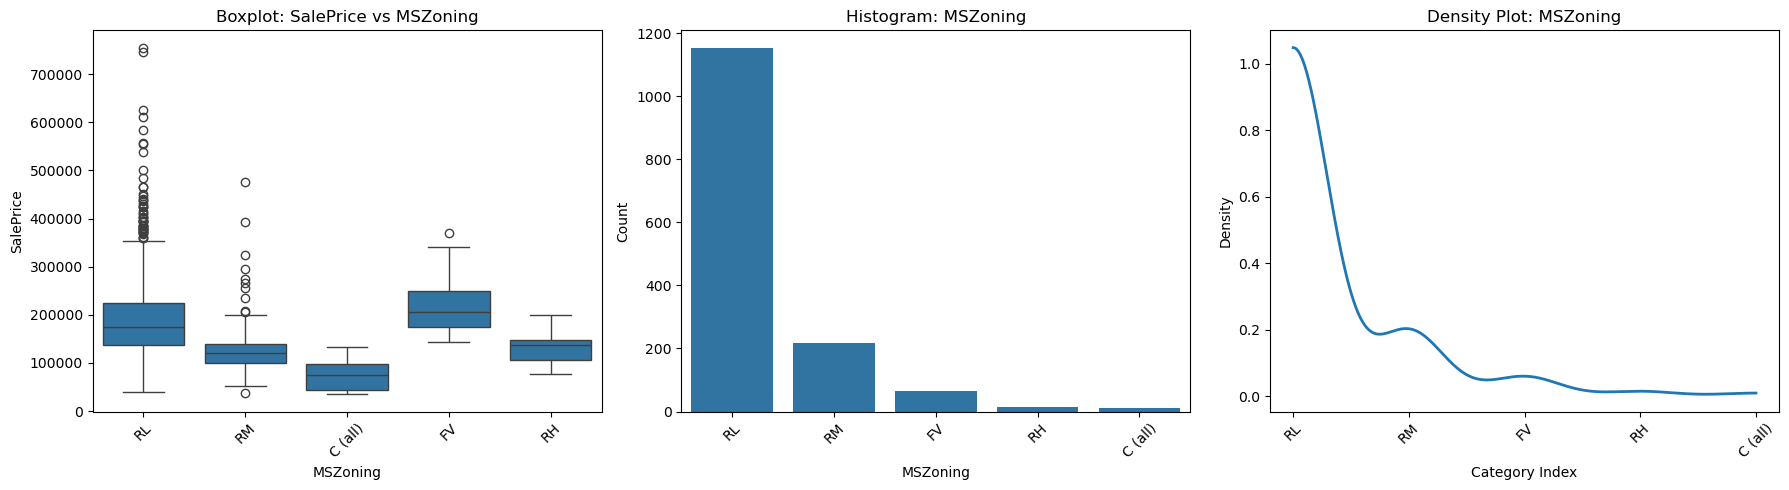

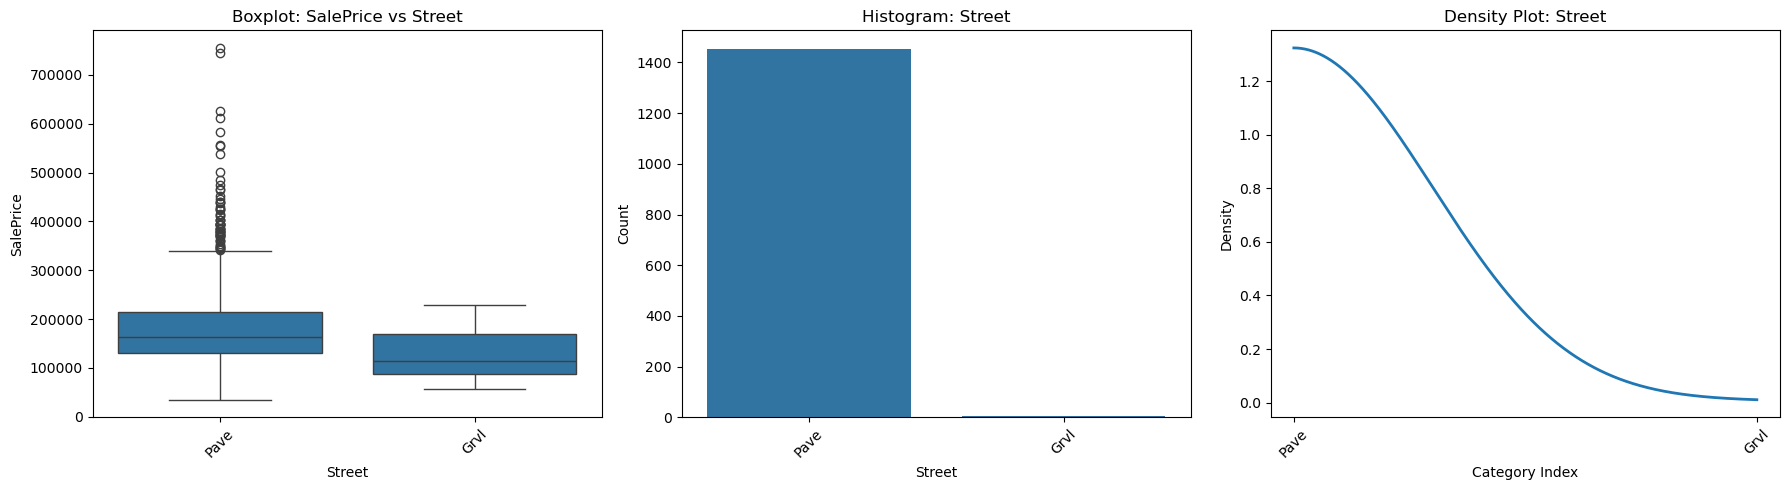

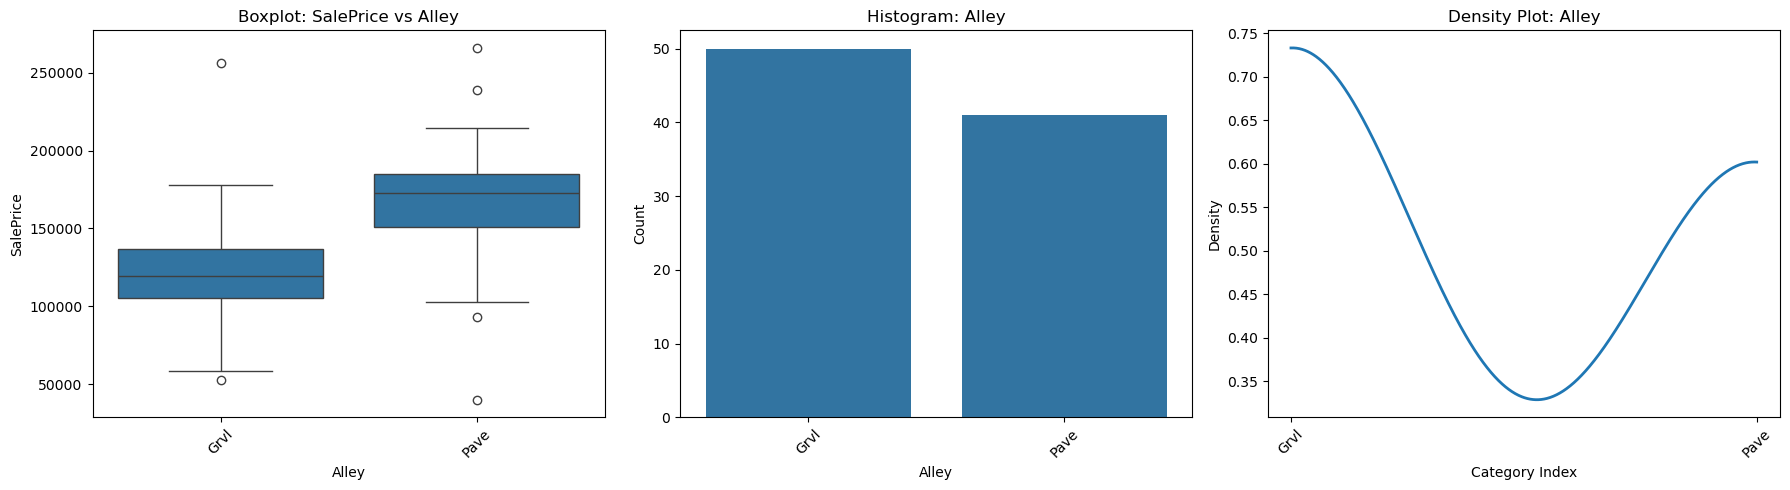

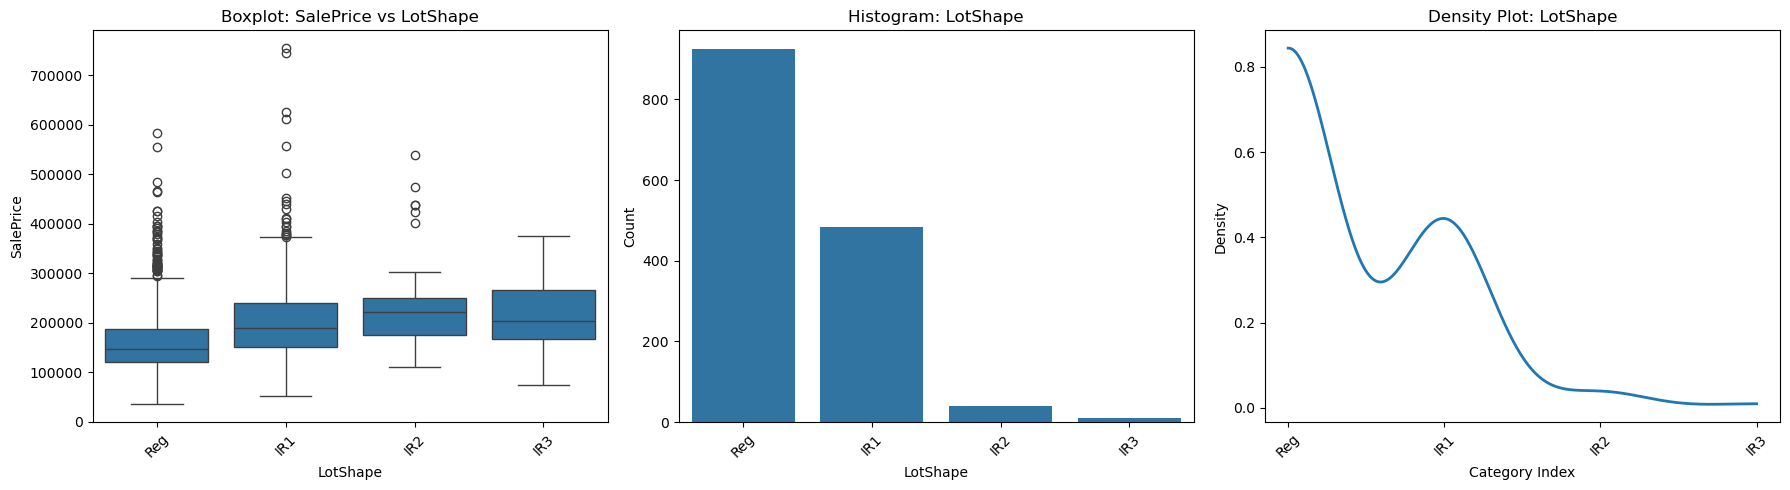

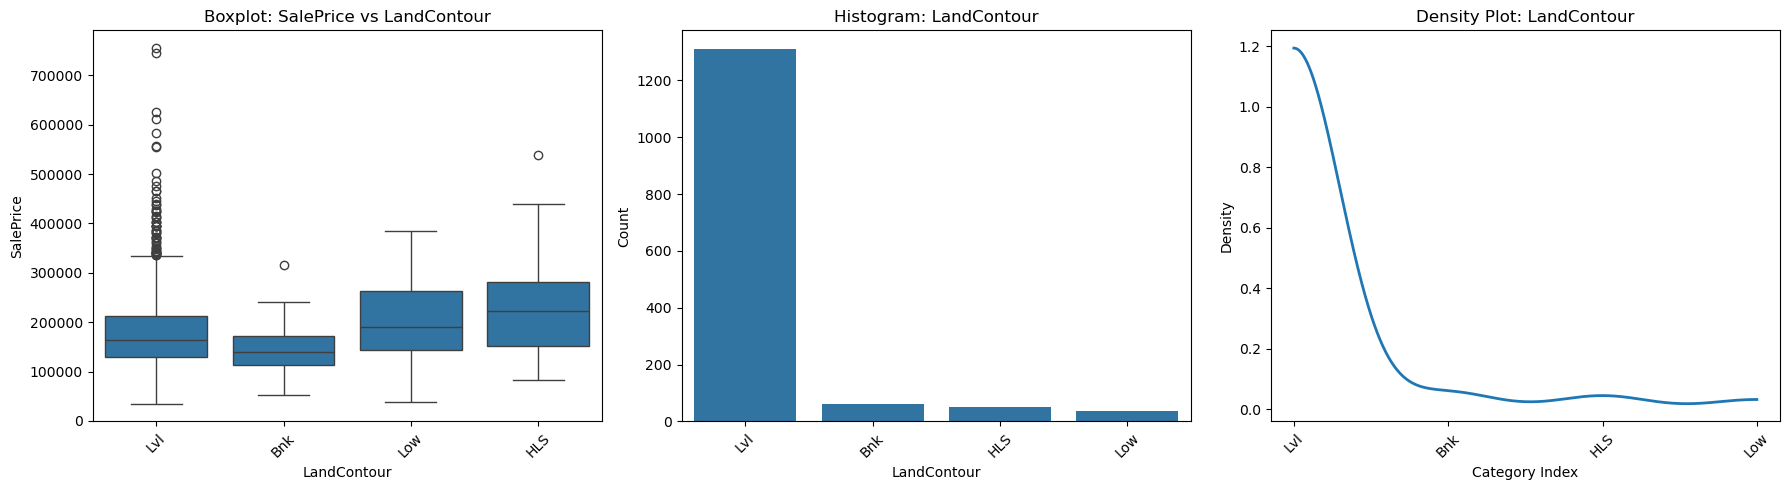

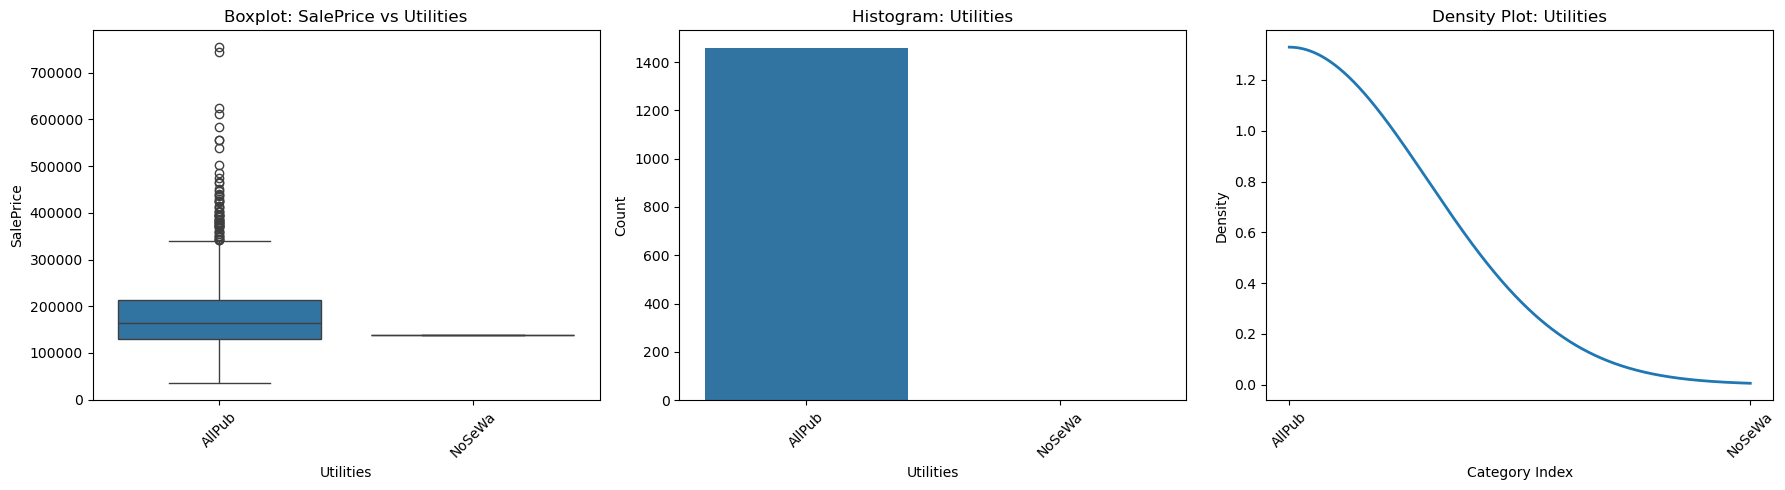

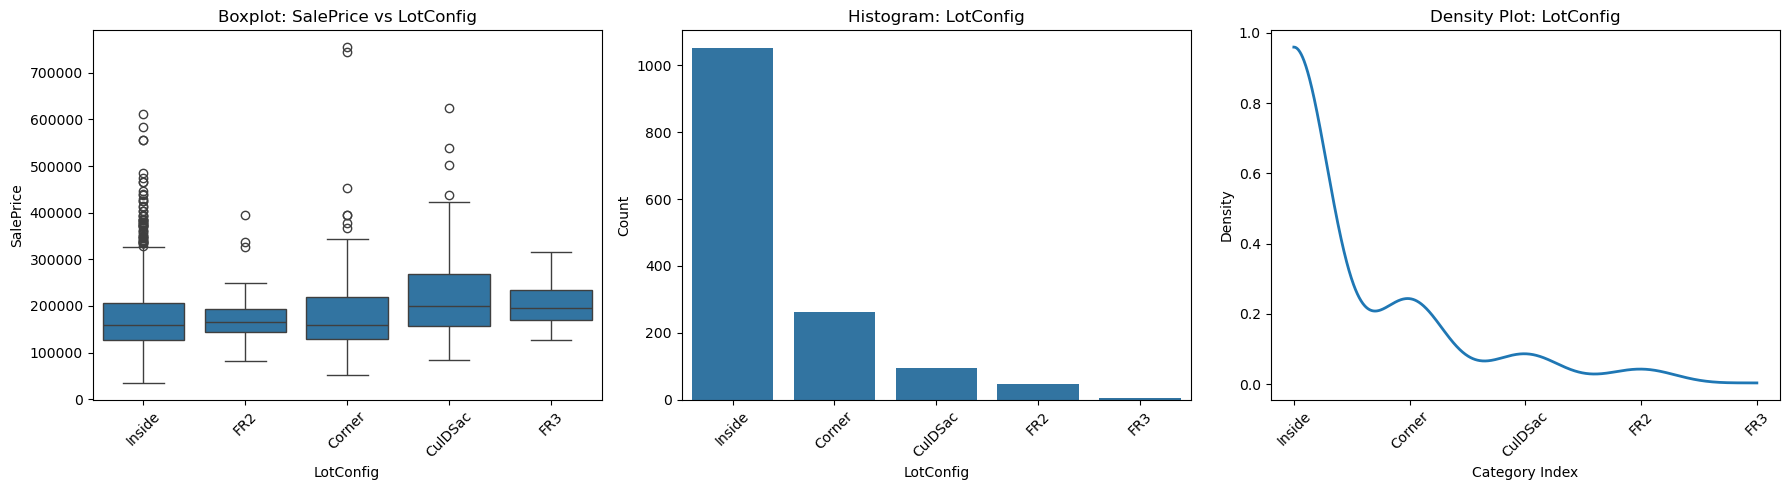

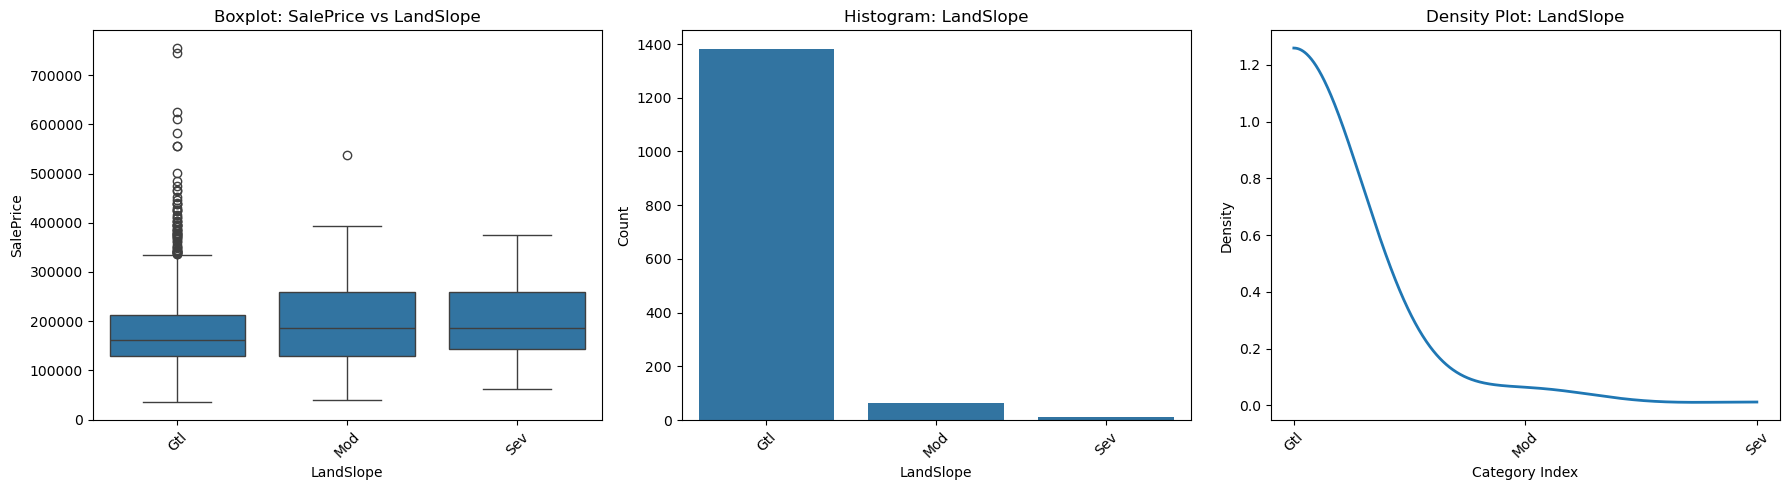

Bỏ qua cột 'Neighborhood' vì có quá nhiều giá trị (25)


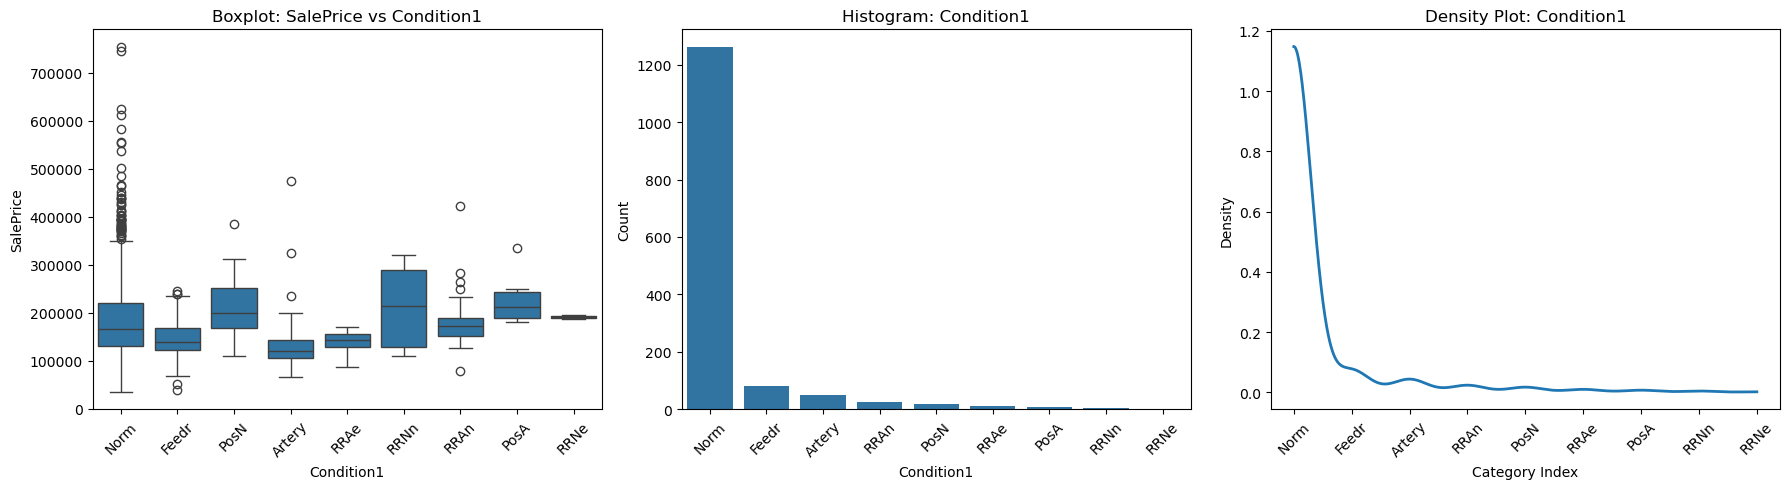

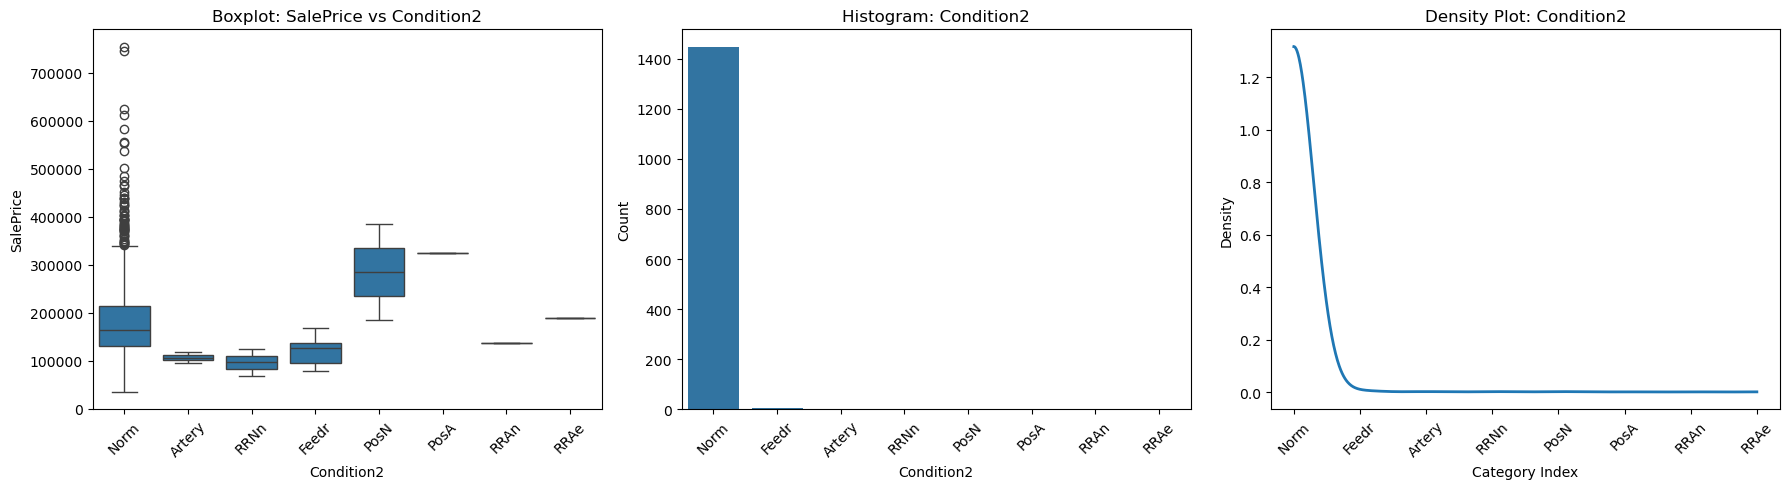

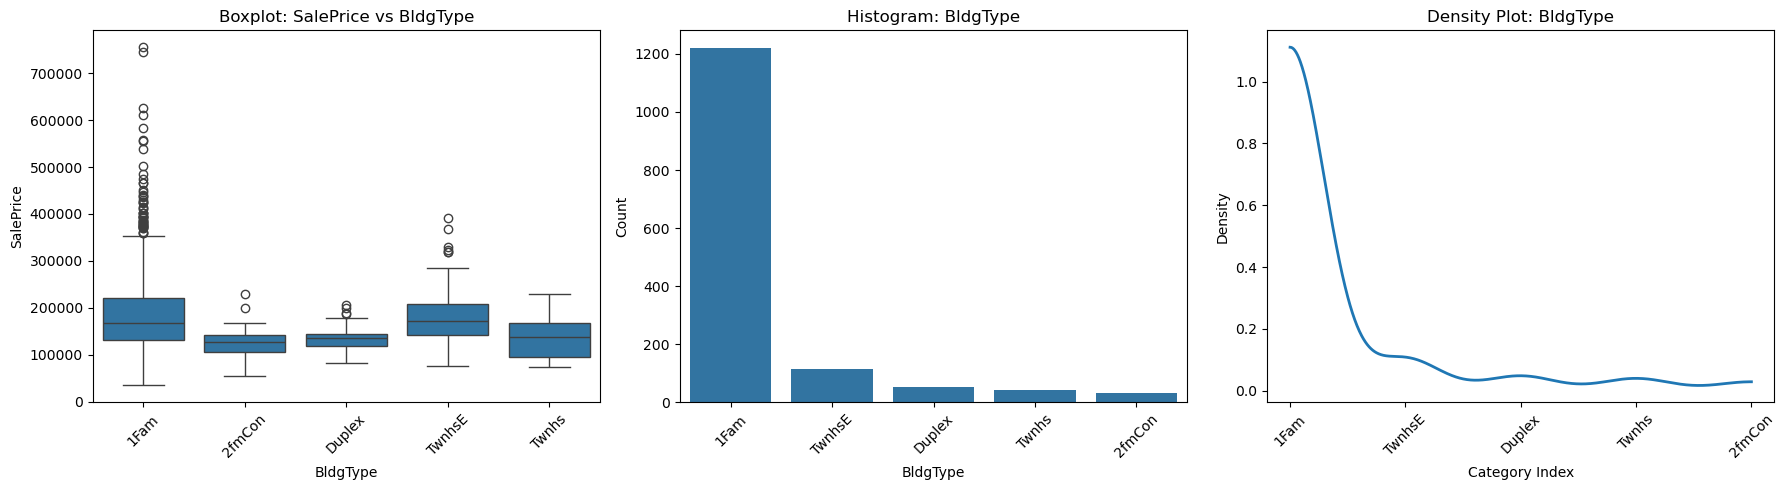

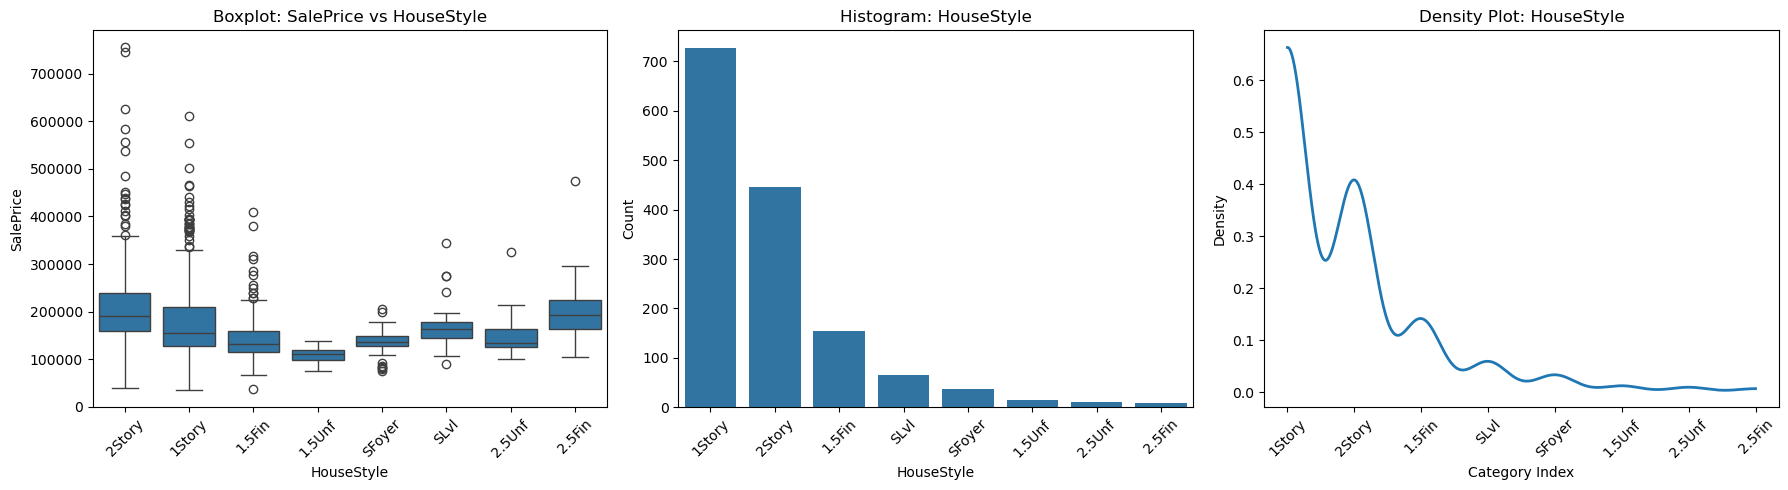

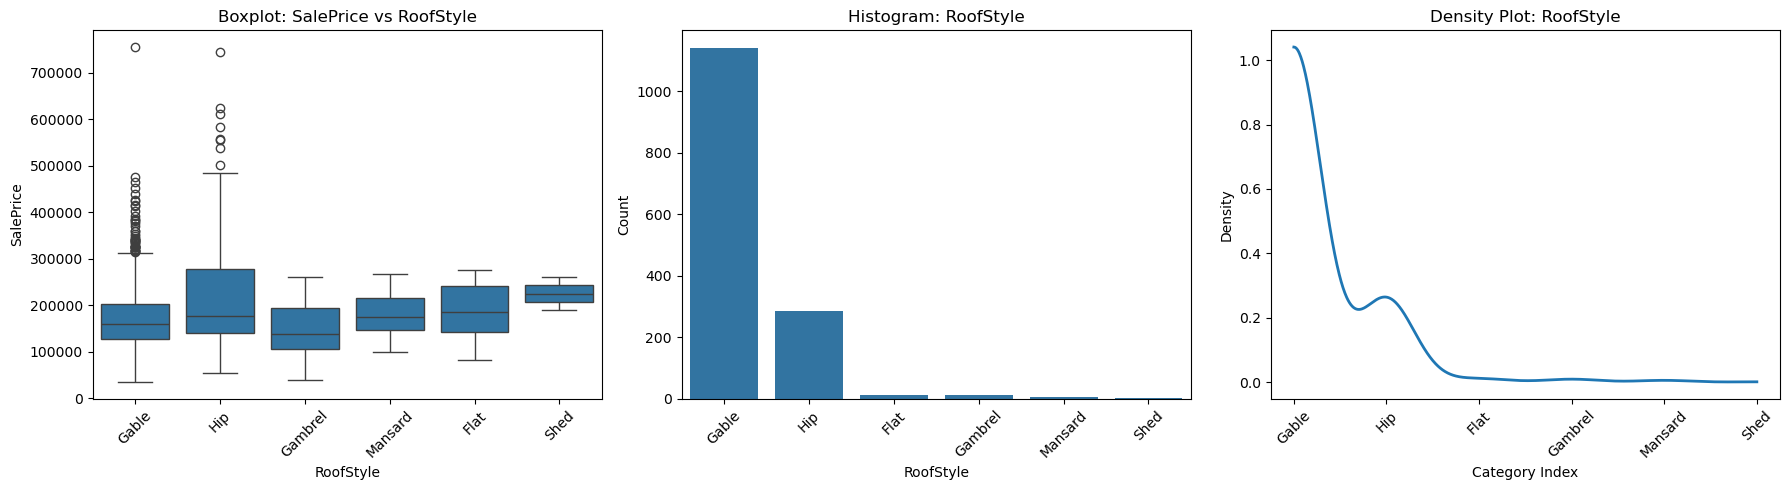

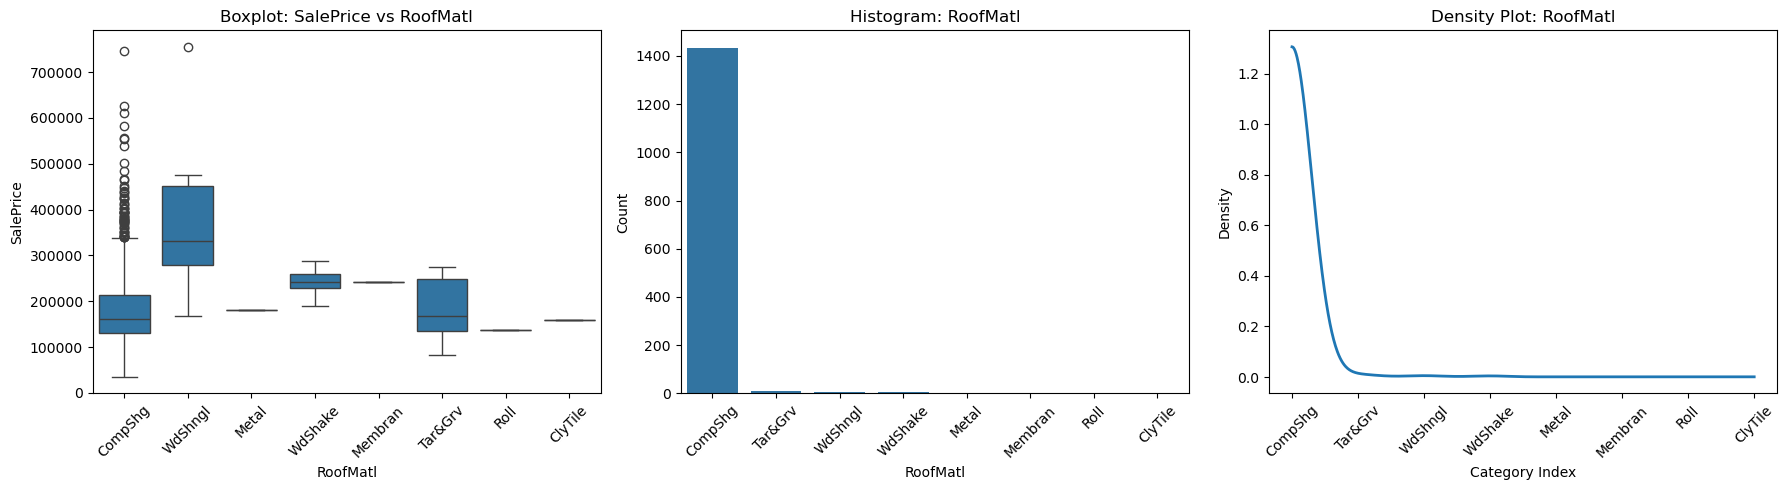

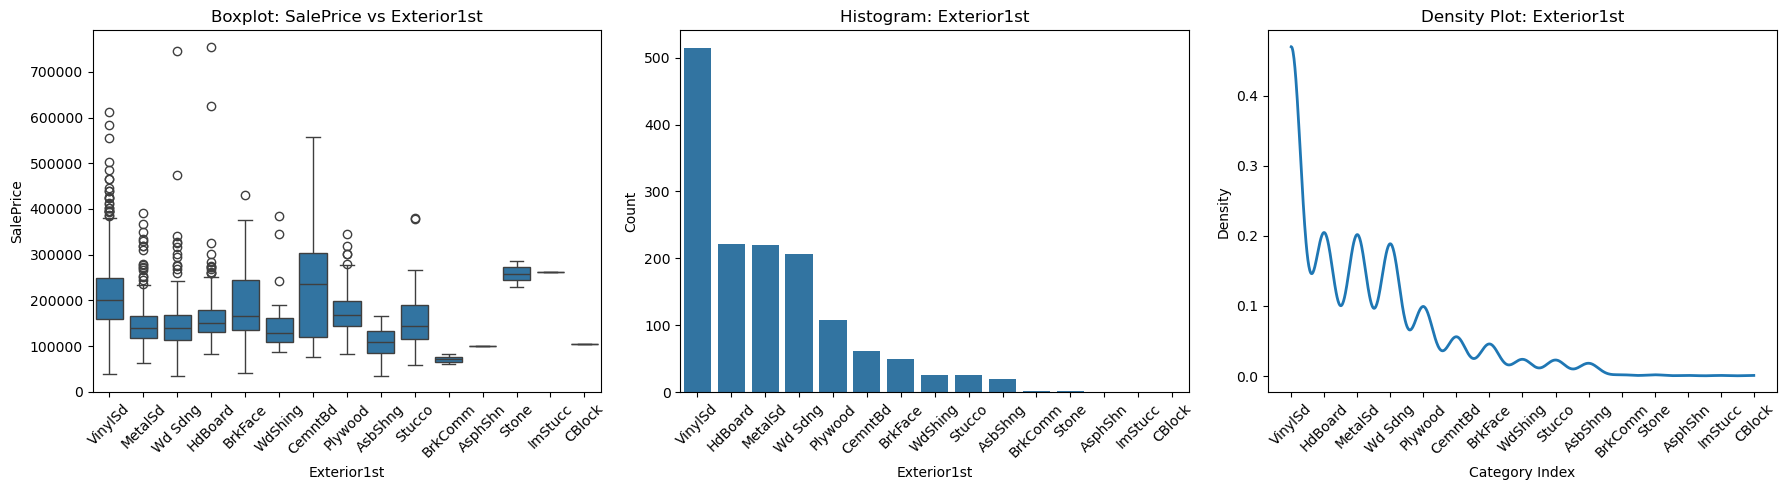

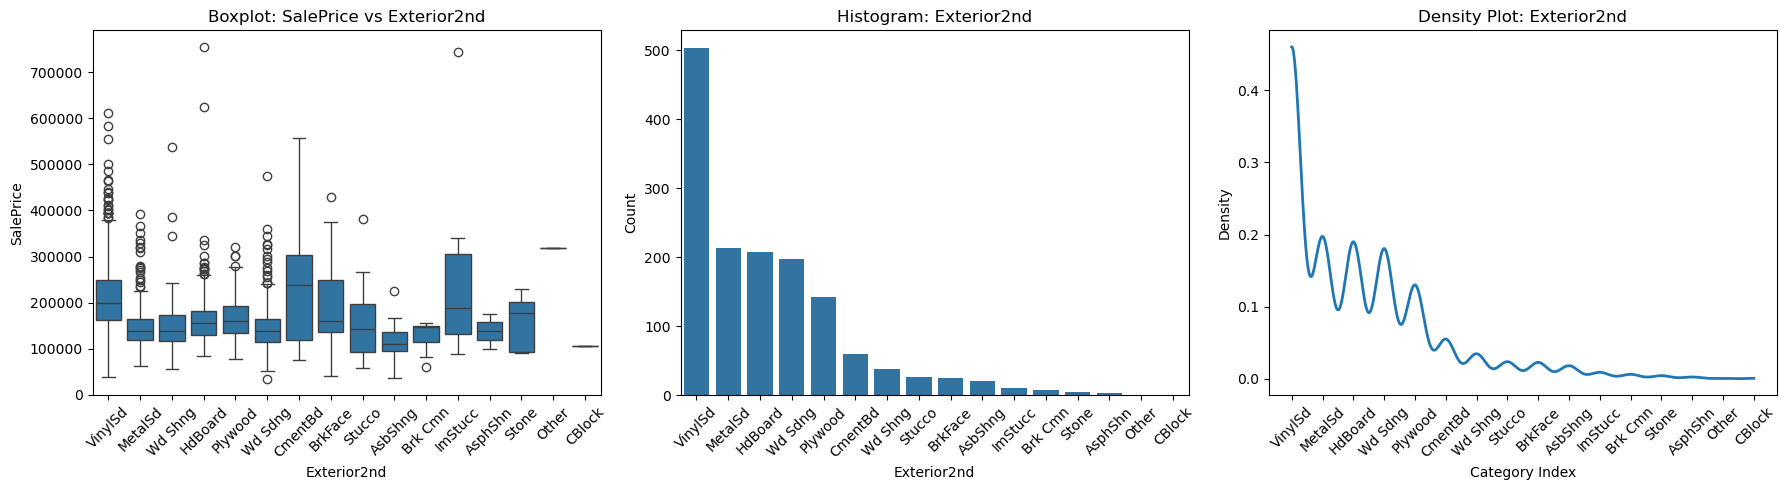

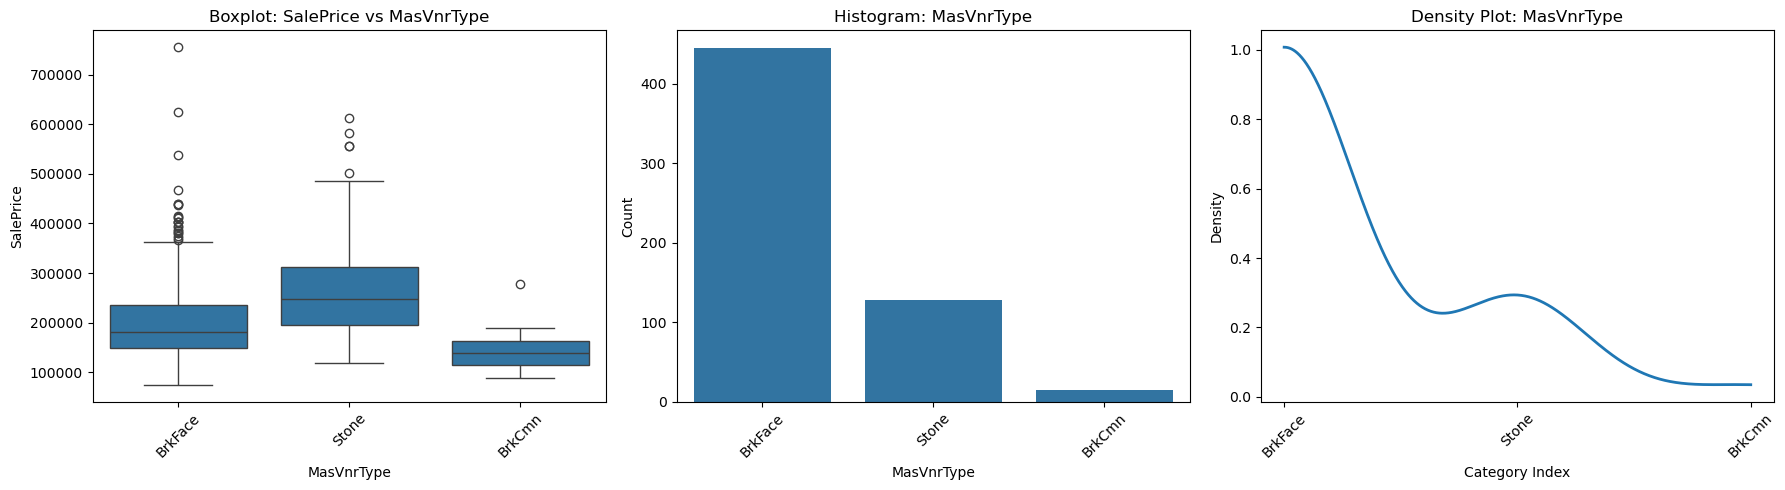

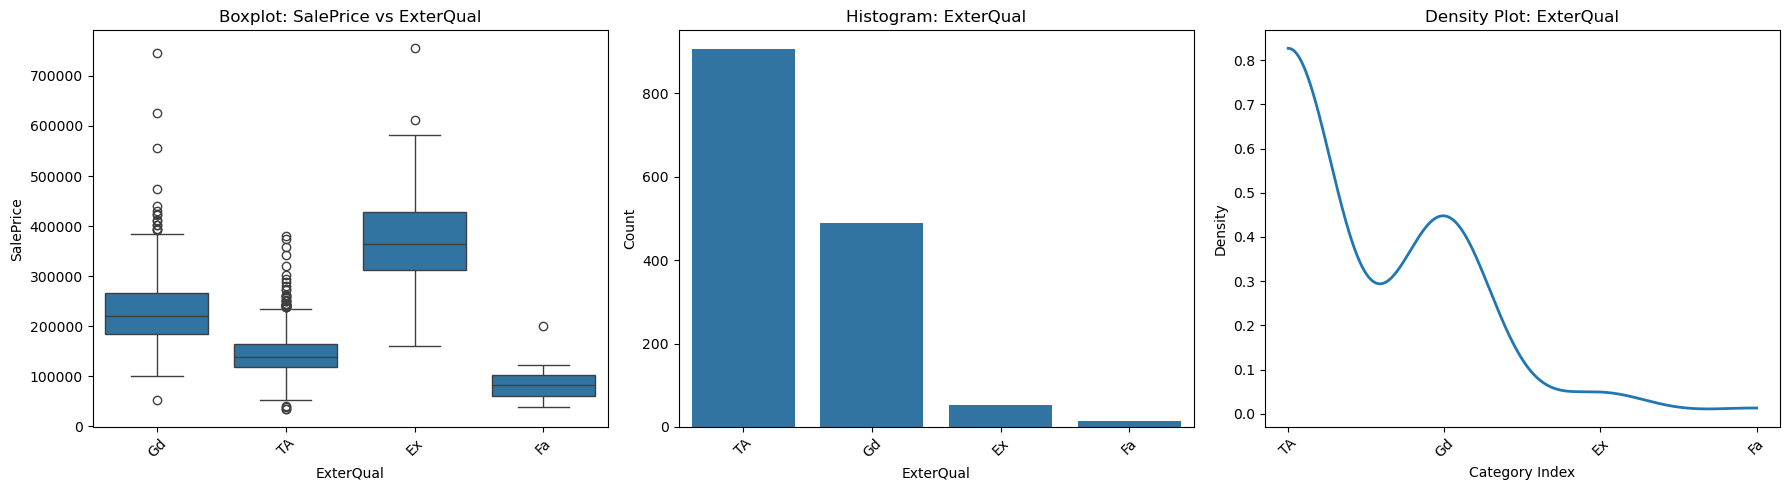

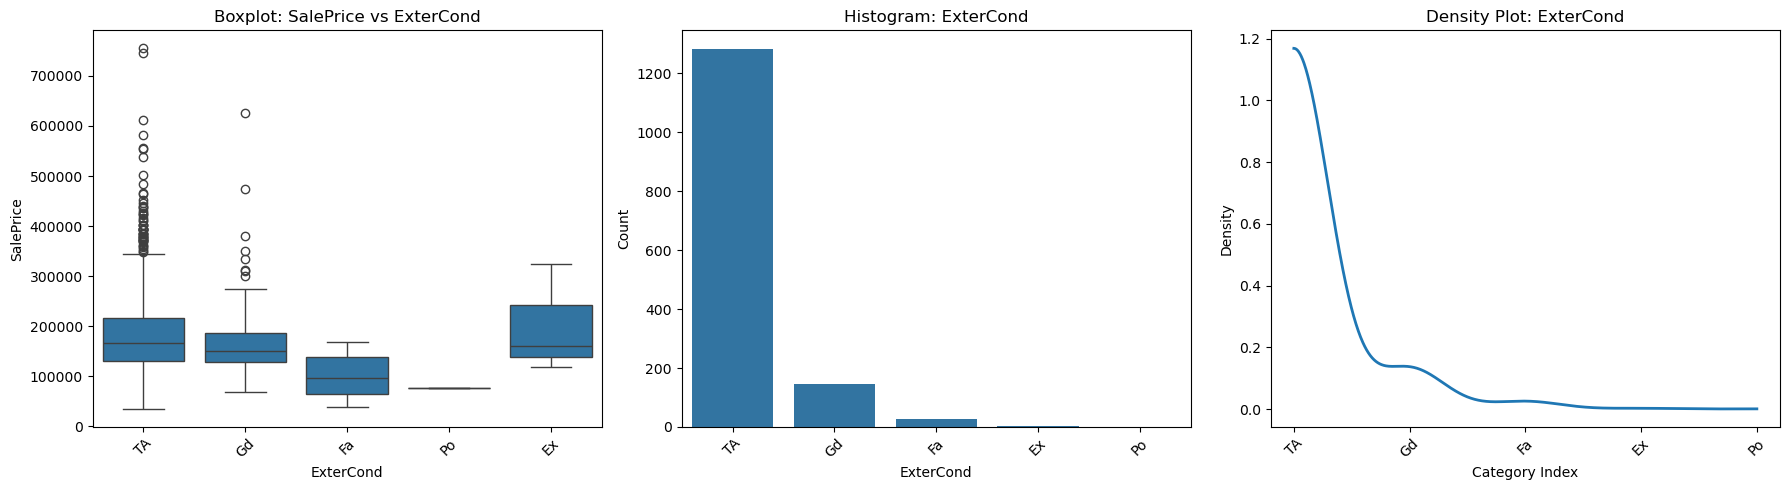

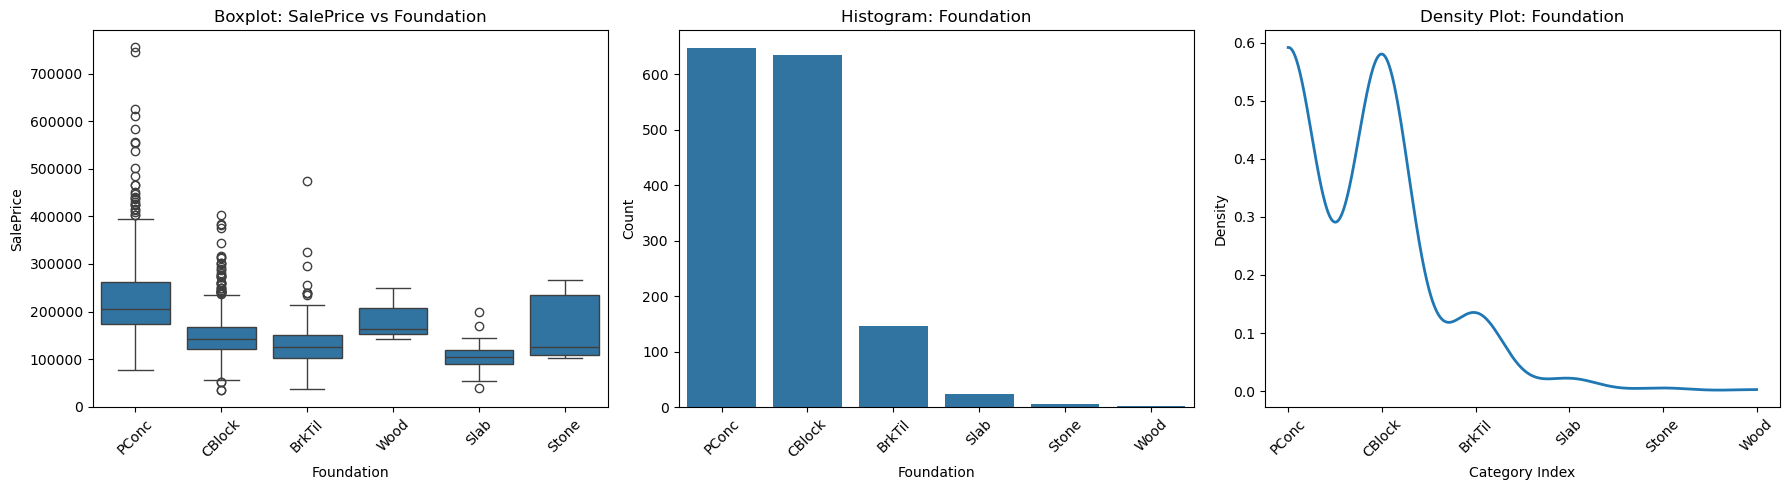

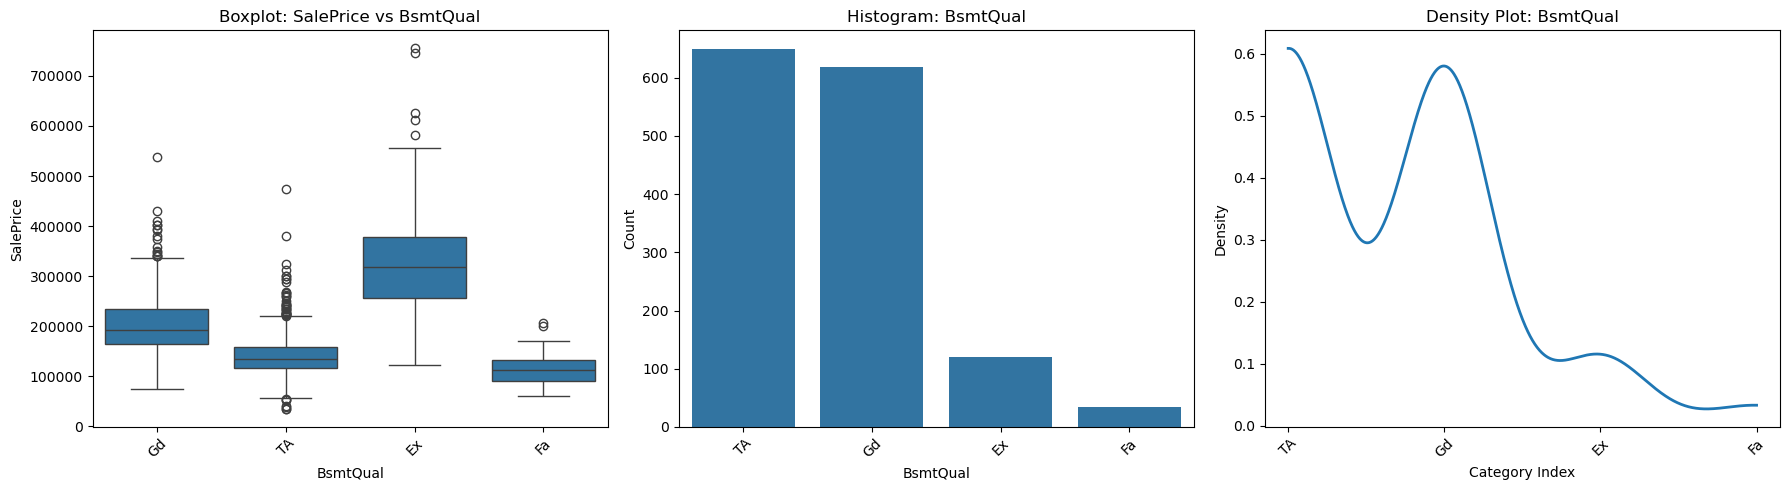

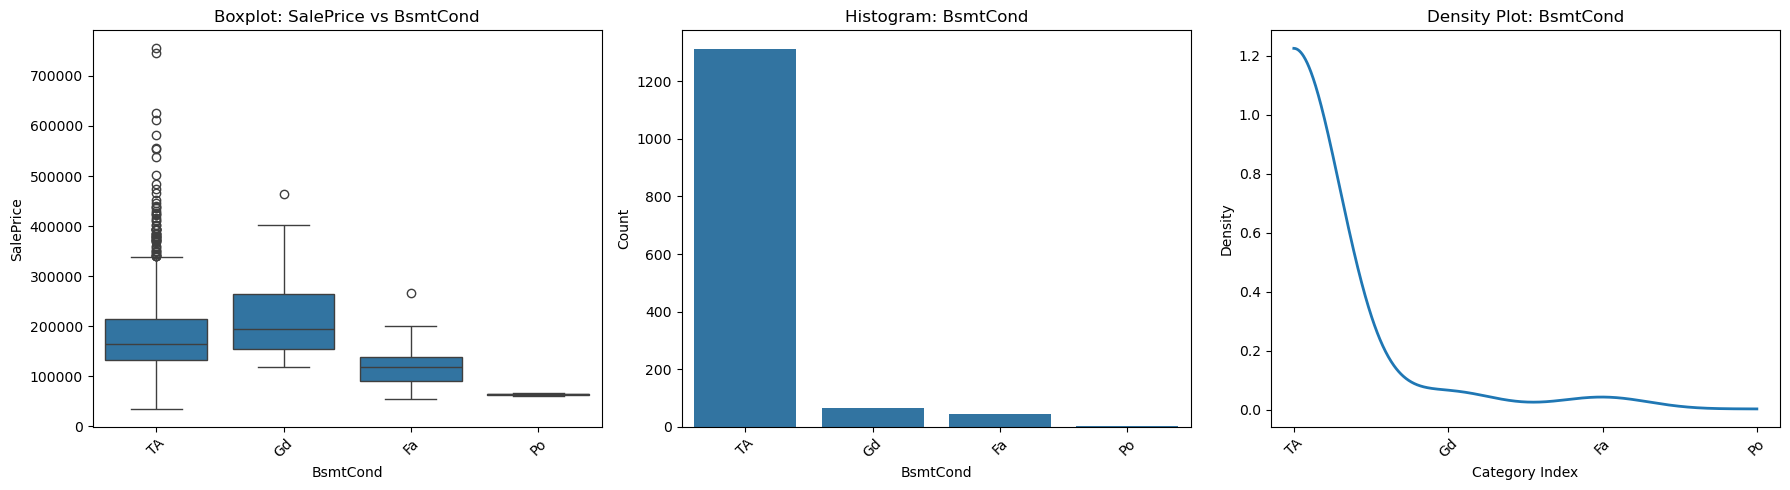

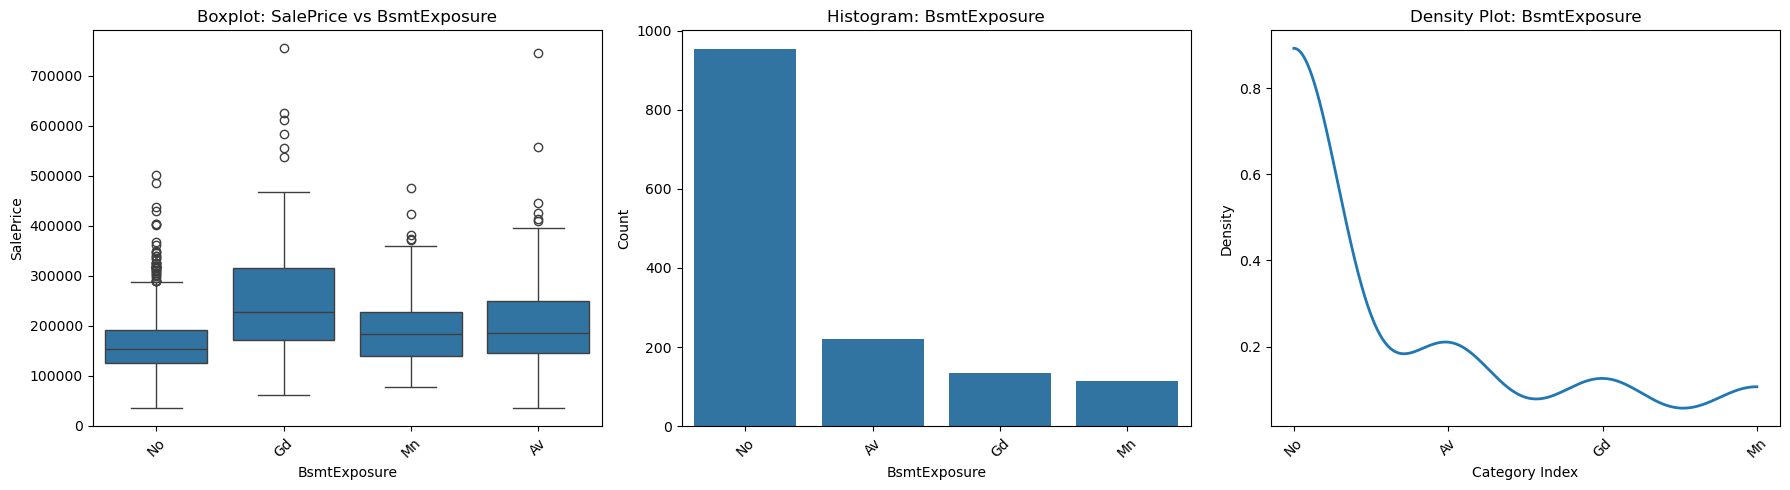

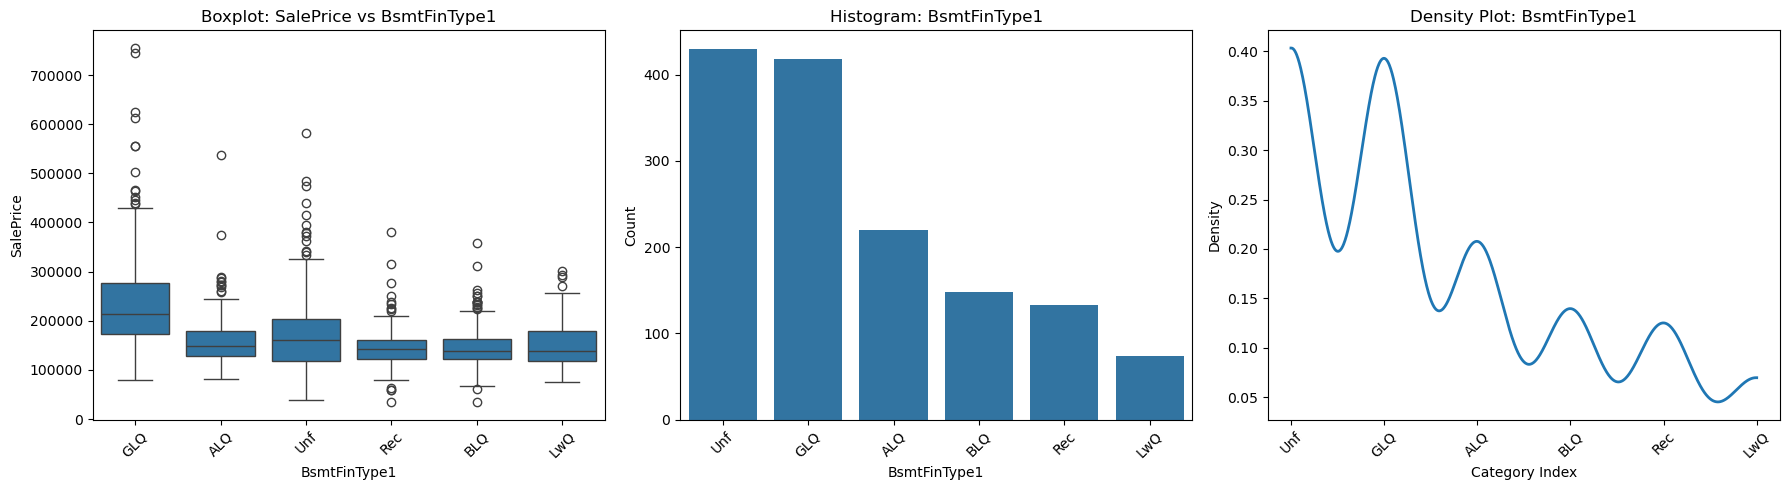

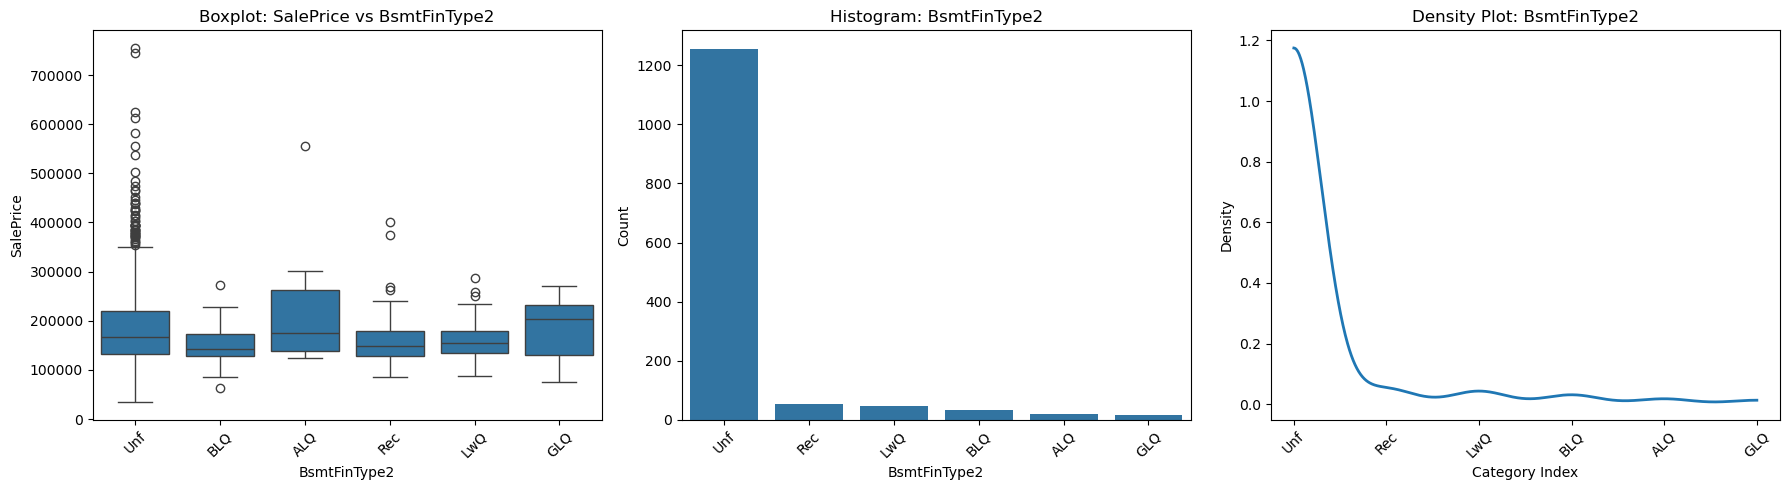

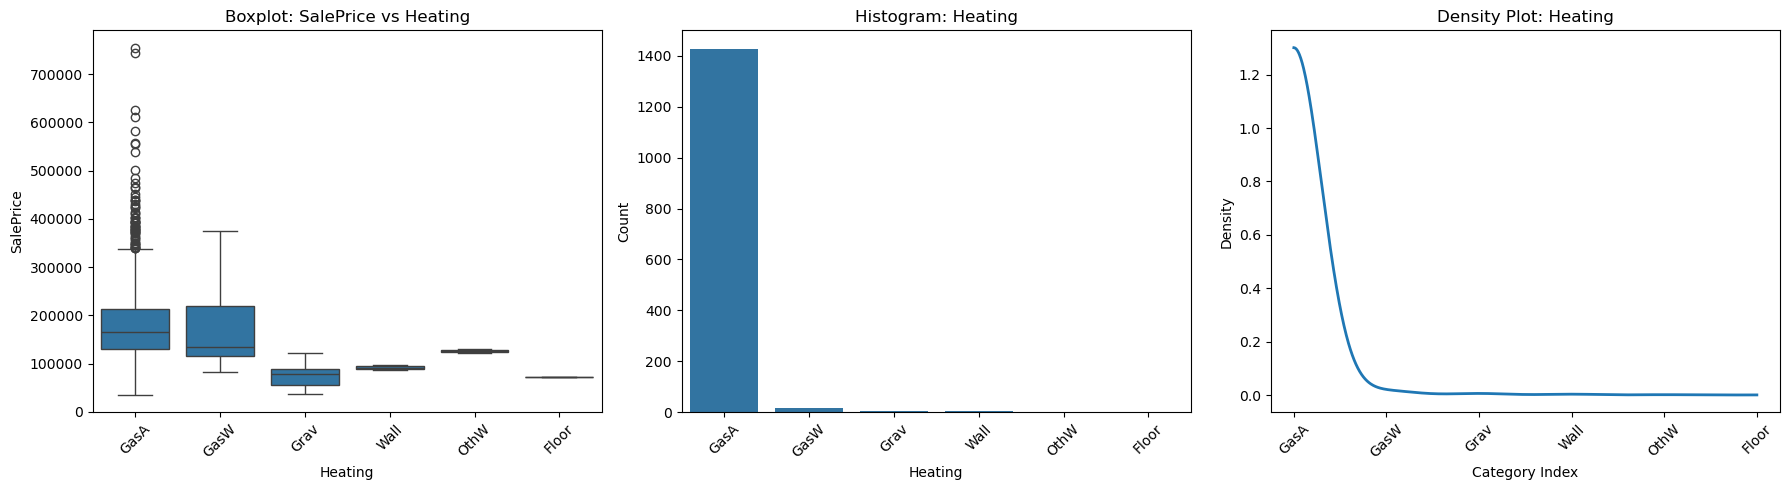

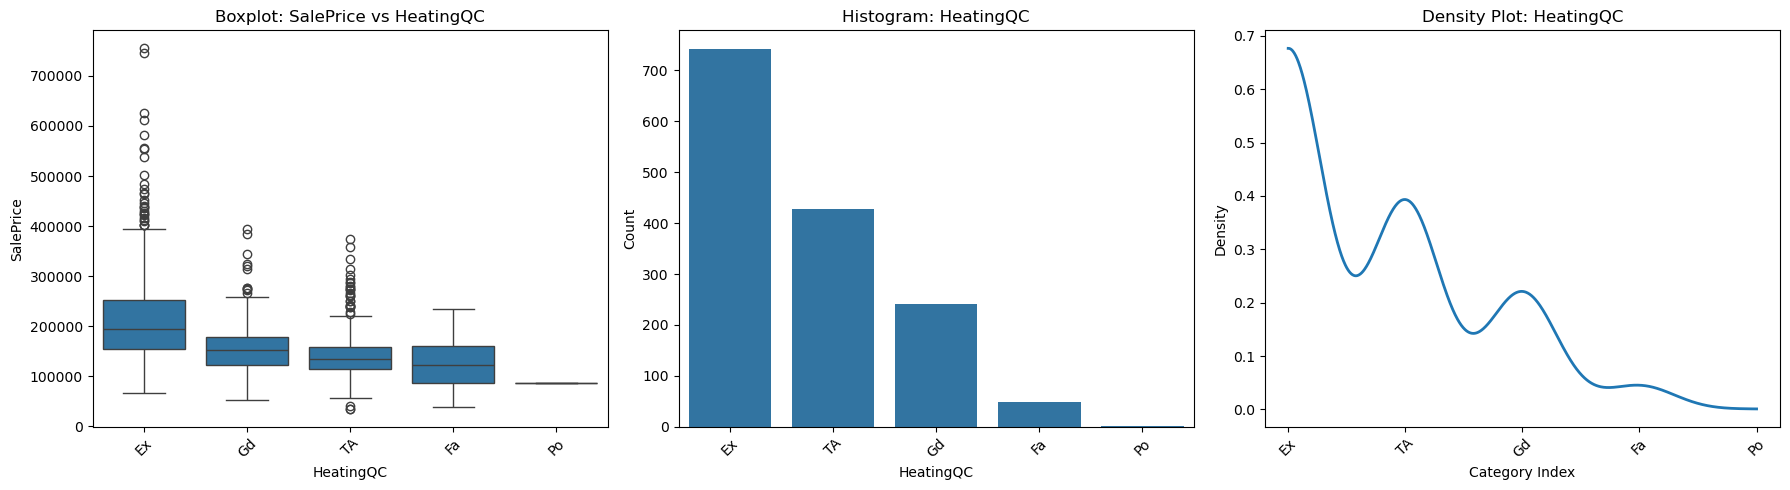

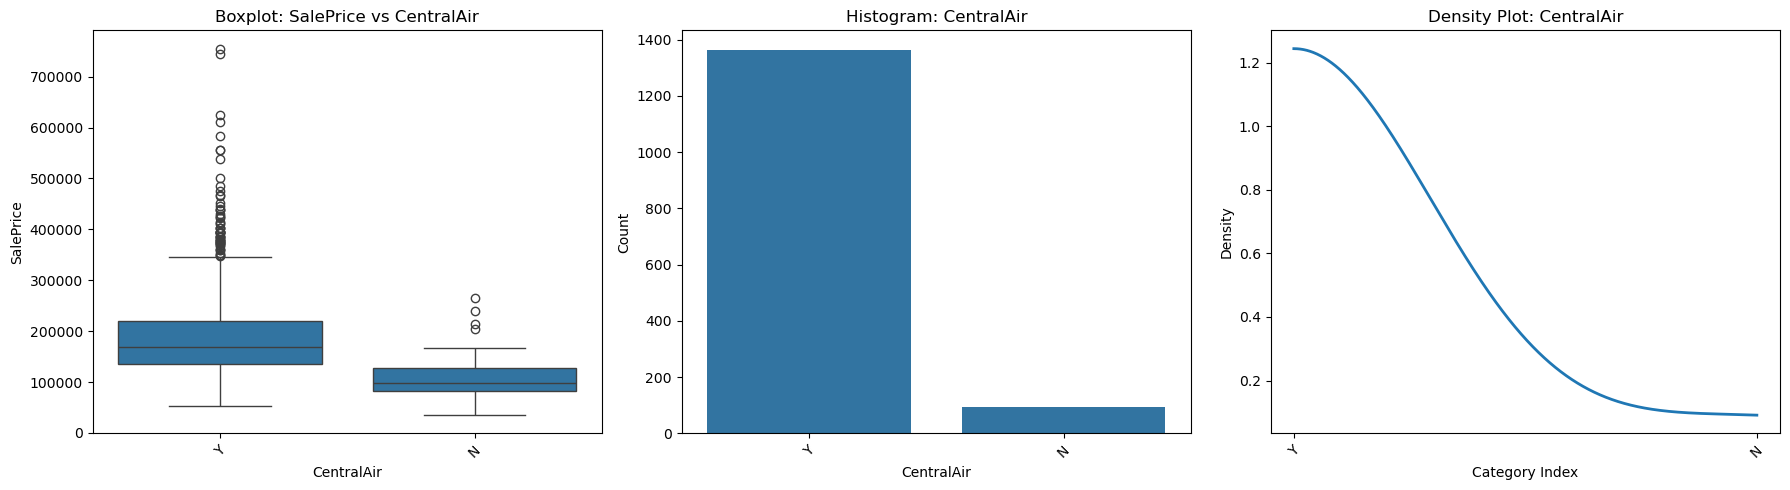

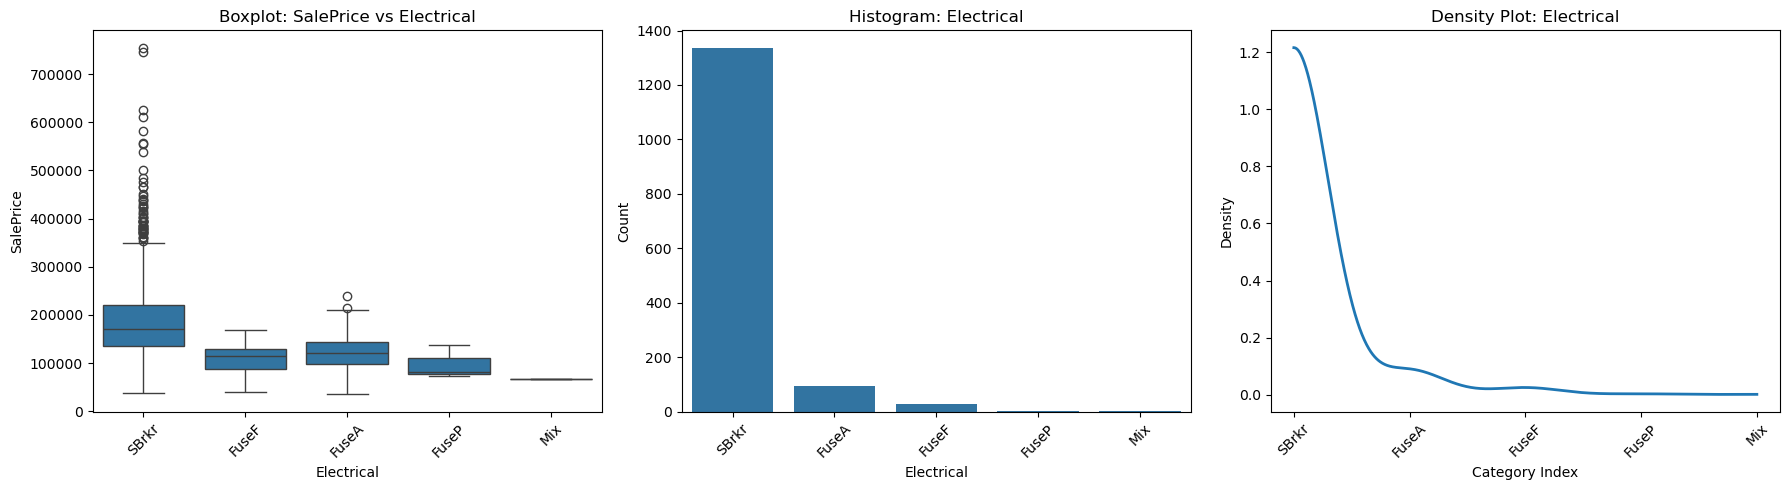

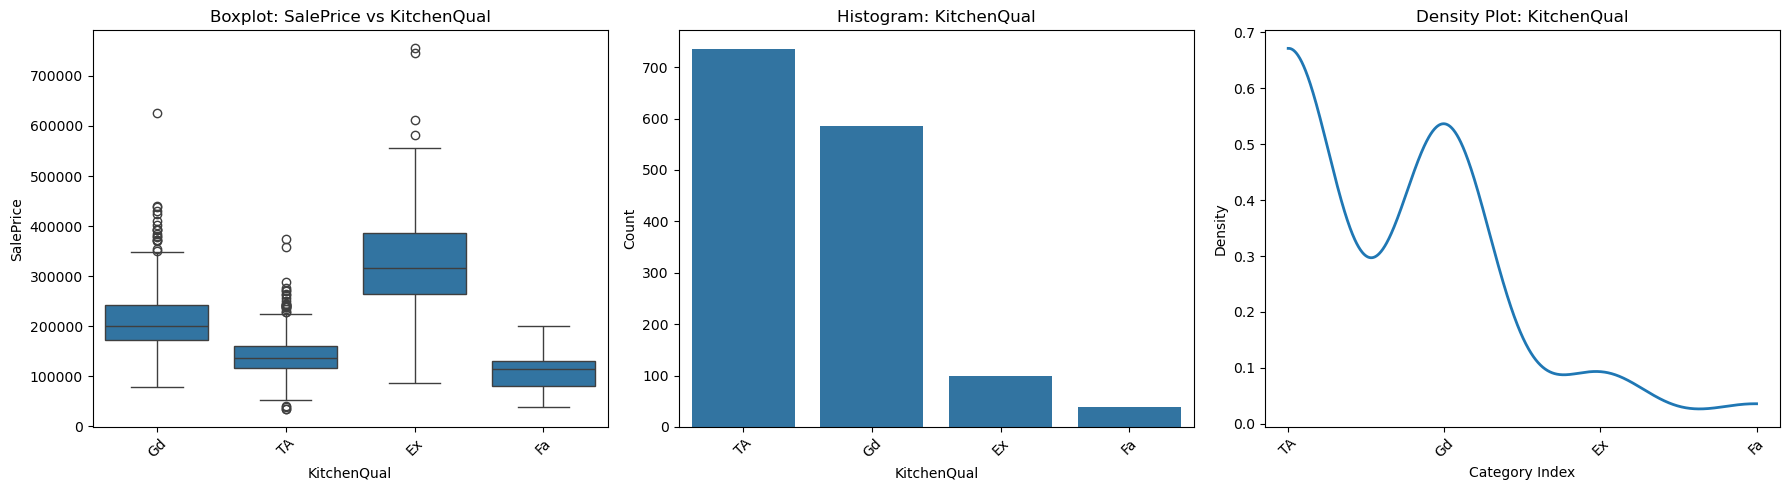

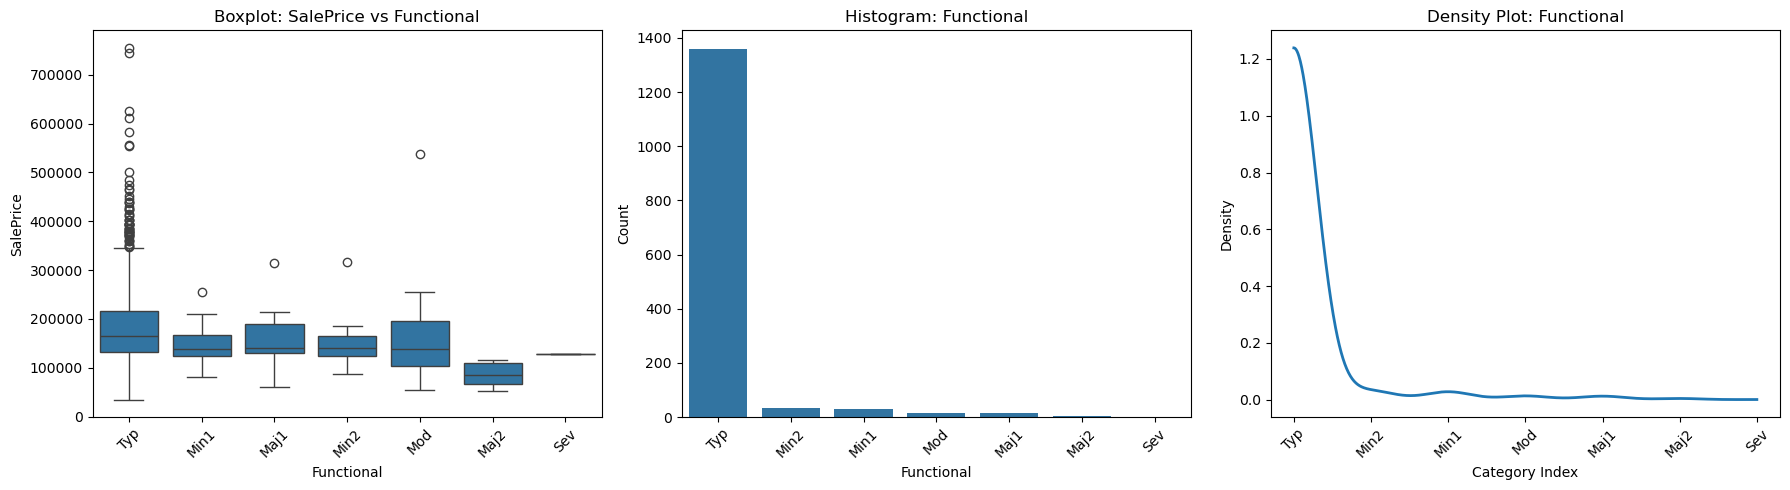

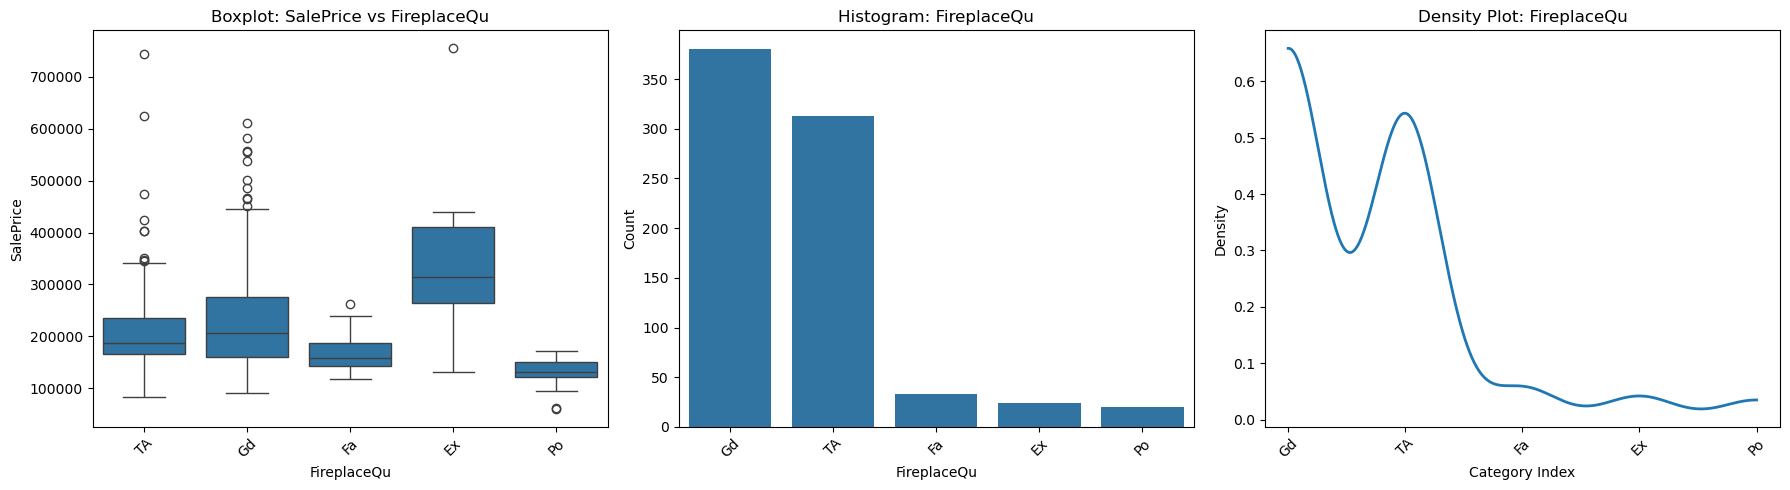

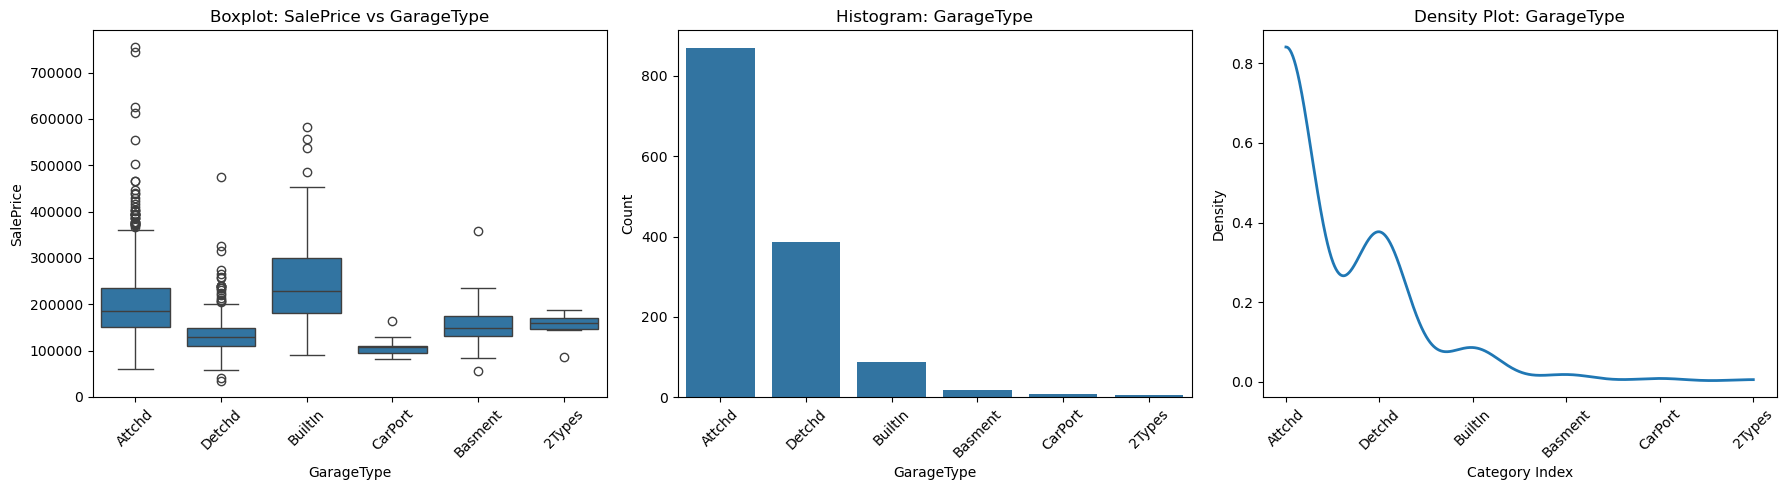

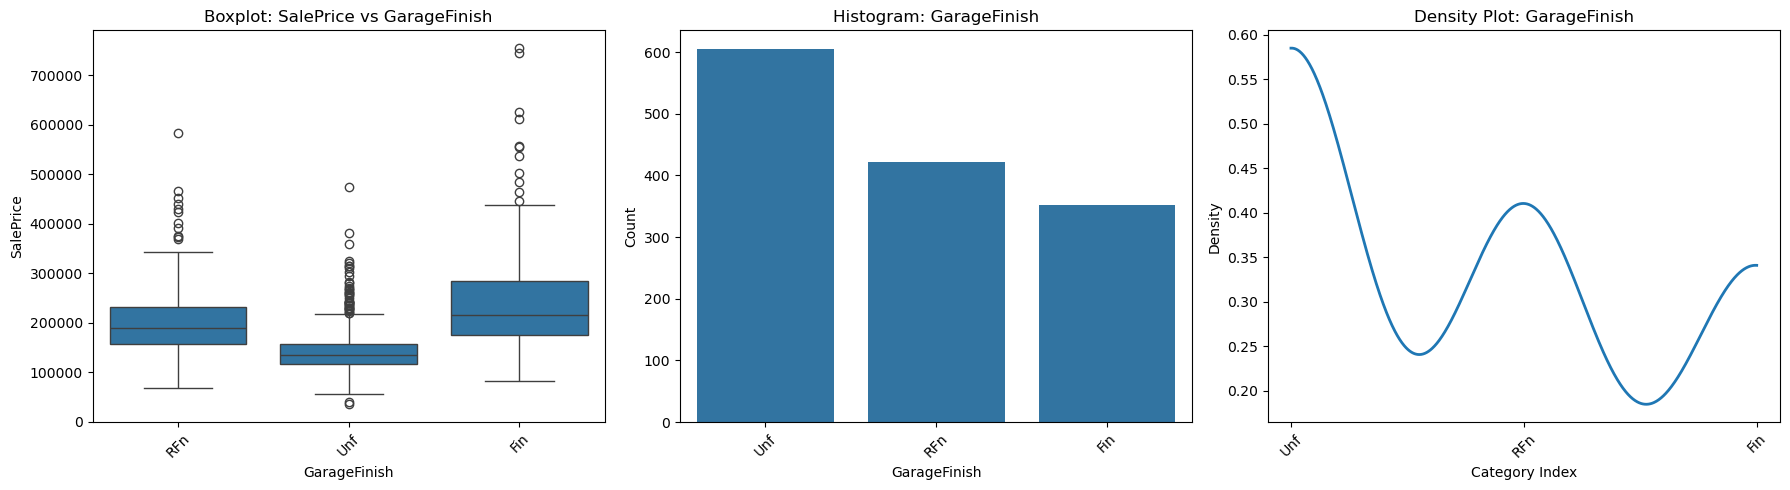

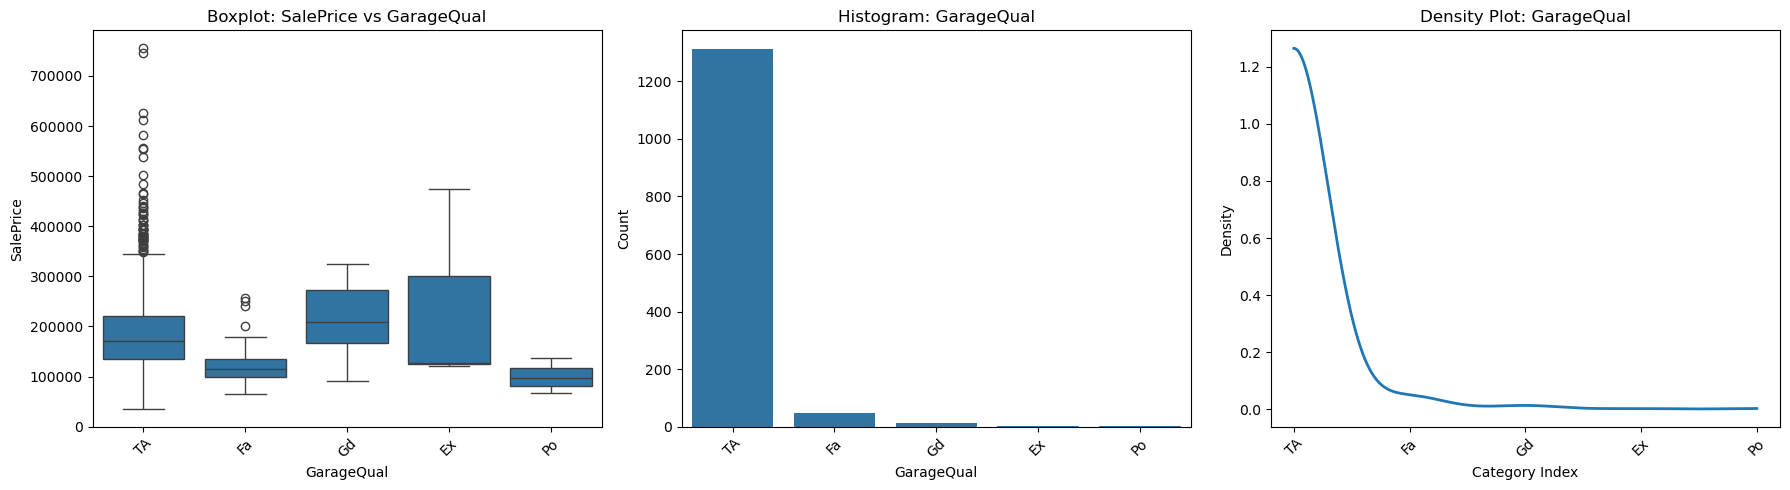

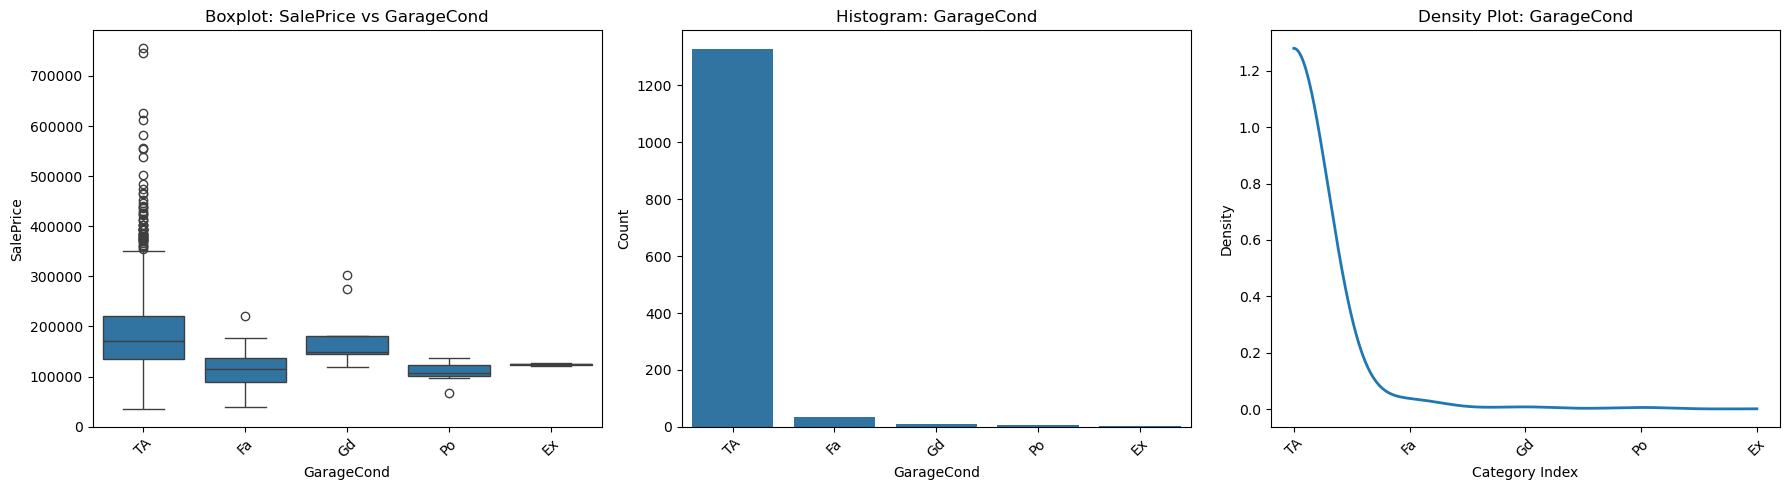

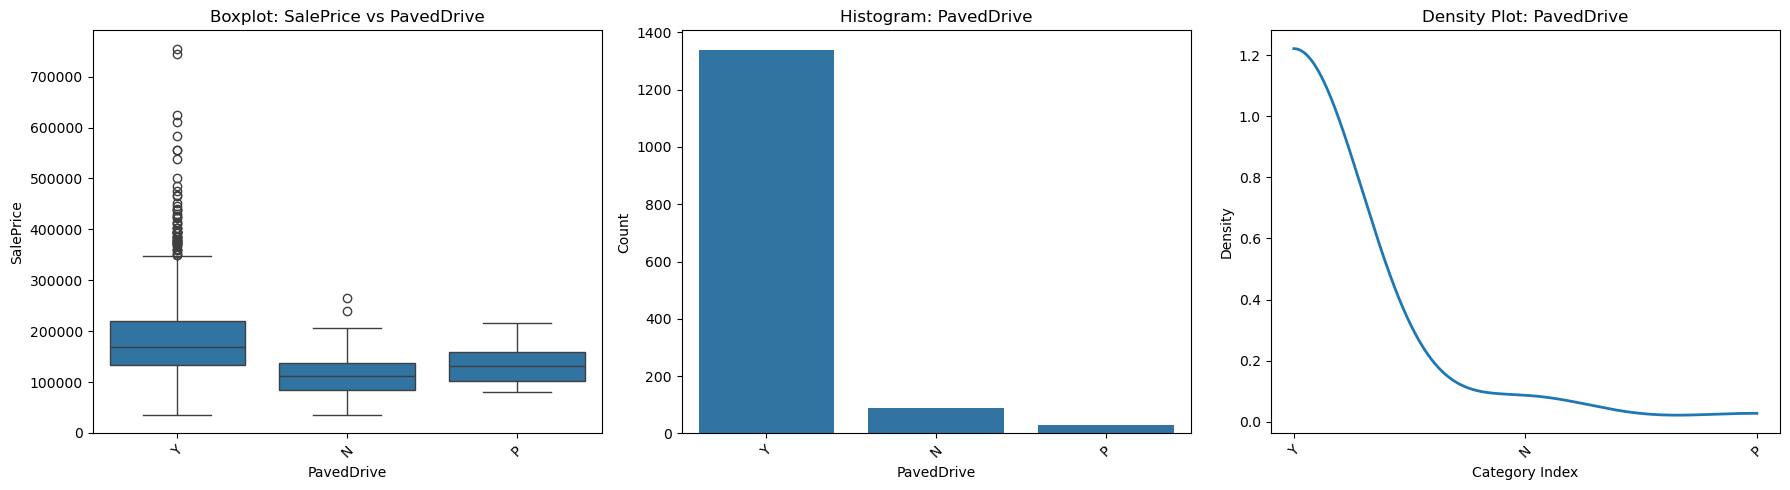

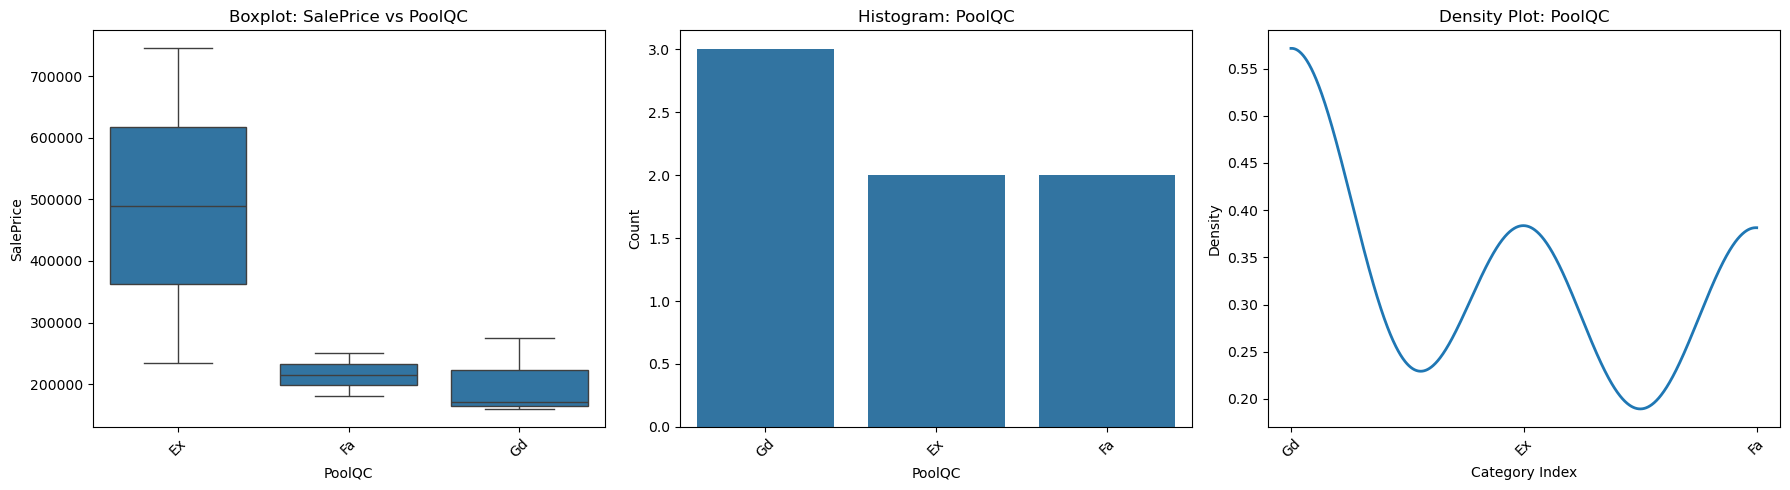

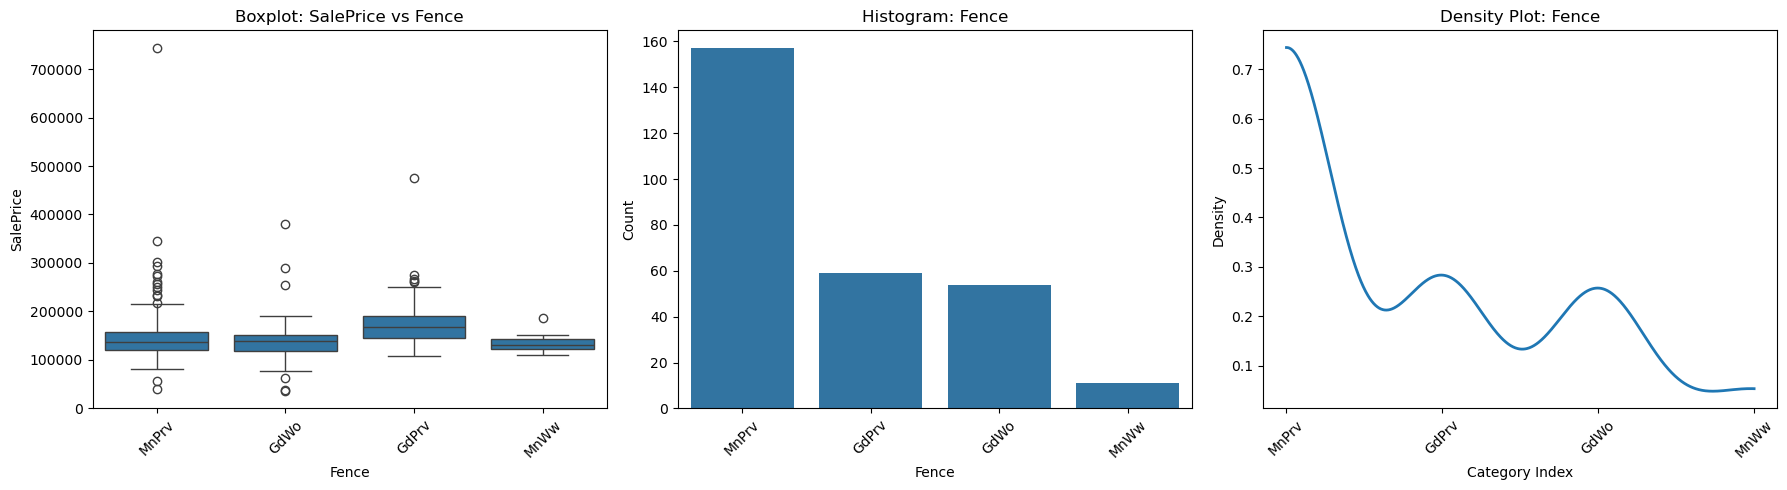

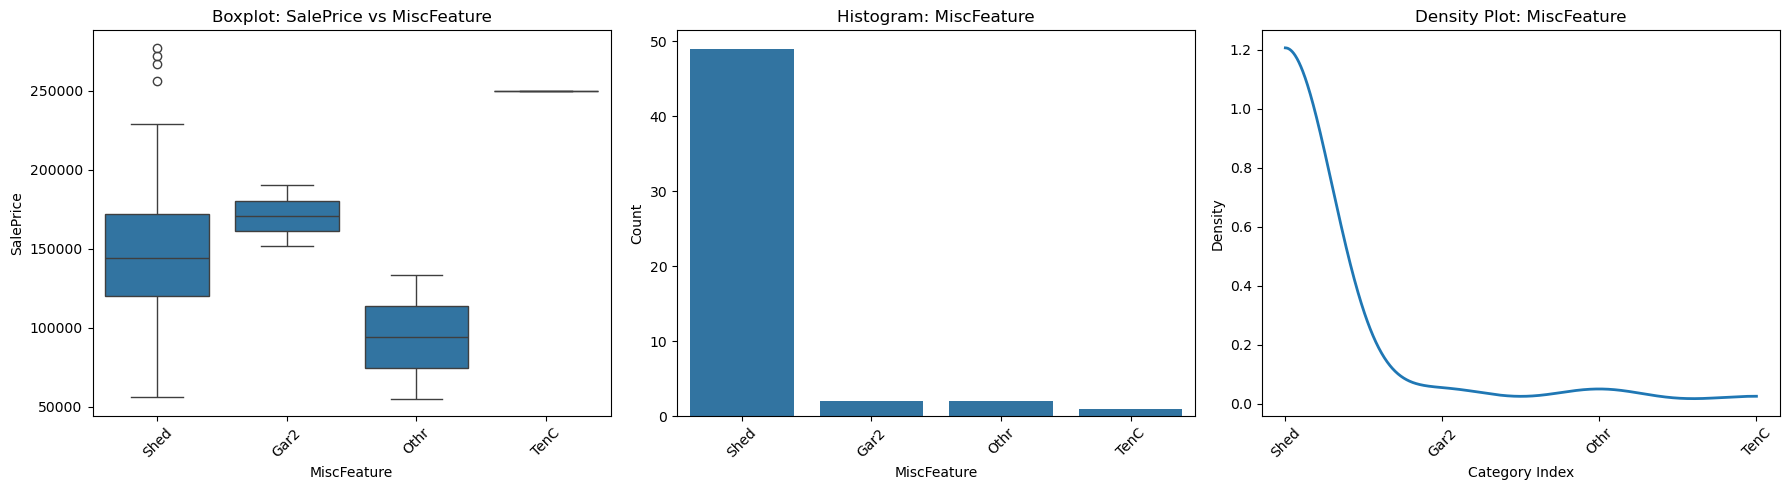

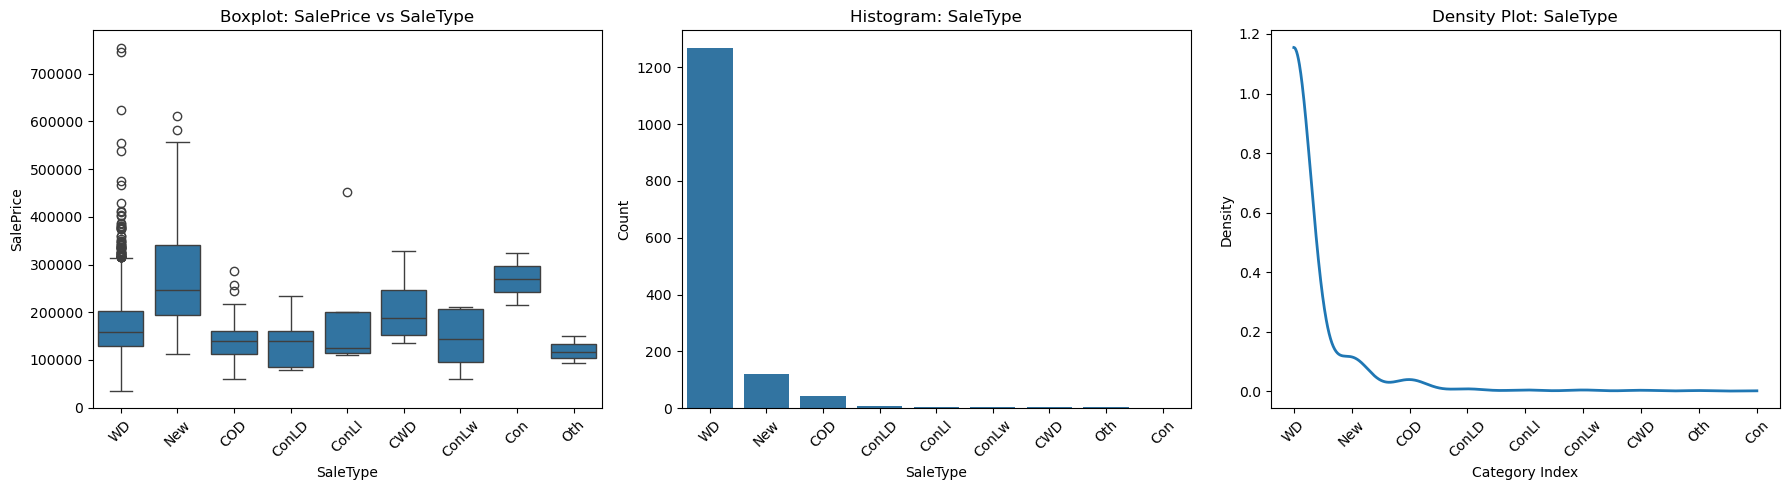

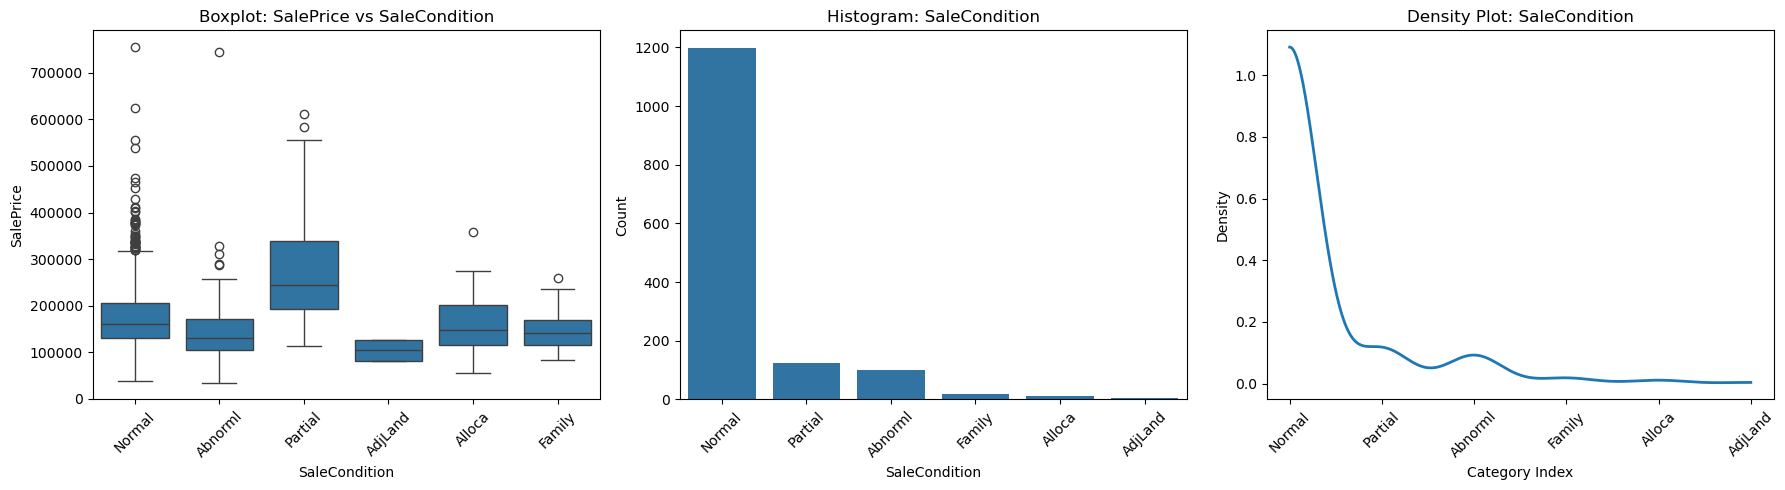

In [8]:
def plot_box_hist_density(df, categorical_columns=None, numeric_columns=None, max_categories=20):
    """
    Vẽ boxplot, histogram và density plot cho các cột category và numeric.

    Parameters:
    - df: DataFrame chứa dữ liệu
    - categorical_columns: danh sách cột dạng category (nếu không truyền sẽ tự động chọn)
    - numeric_columns: danh sách cột dạng số (nếu không truyền sẽ tự động chọn)
    - max_categories: số lượng giá trị duy nhất tối đa để vẽ (tránh quá nhiều nhãn)
    """
    if categorical_columns is None:
        categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if numeric_columns is None:
        numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    for cat_col in categorical_columns:
        unique_vals = df[cat_col].dropna().unique()
        if len(unique_vals) > max_categories:
            print(f"Bỏ qua cột '{cat_col}' vì có quá nhiều giá trị ({len(unique_vals)})")
            continue

        for num_col in numeric_columns:
            plt.figure(figsize=(18, 5))

            # Boxplot (giữ nguyên)
            plt.subplot(1, 3, 1)
            sns.boxplot(data=df, x=cat_col, y=num_col)
            plt.title(f"Boxplot: {num_col} vs {cat_col}")
            plt.xticks(rotation=45)

            # Histogram theo value count
            plt.subplot(1, 3, 2)
            value_counts = df[cat_col].value_counts()
            sns.barplot(x=value_counts.index, y=value_counts.values)
            plt.title(f"Histogram: {cat_col}")
            plt.xlabel(cat_col)
            plt.ylabel("Count")
            plt.xticks(rotation=45)

            # Density plot theo value count (sử dụng KDE trên phân phối tỷ lệ)
            plt.subplot(1, 3, 3)
            proportions = df[cat_col].value_counts(normalize=True)
            
            # Tạo dữ liệu liên tục giả cho KDE
            x_vals = np.linspace(0, len(proportions) - 1, 1000)
            kde_vals = np.zeros_like(x_vals)
            
            for i, (category, prop) in enumerate(proportions.items()):
                # Thêm Gaussian kernel cho mỗi category
                kernel = stats.norm(i, 0.3).pdf(x_vals) * prop
                kde_vals += kernel
            
            plt.plot(x_vals, kde_vals, linewidth=2)
            plt.title(f"Density Plot: {cat_col}")
            plt.xlabel("Category Index")
            plt.ylabel("Density")
            plt.xticks(ticks=range(len(proportions)), labels=proportions.index, rotation=45)

            plt.tight_layout()
            plt.show()
plot_box_hist_density(df, categorical_columns=categorical_cols, numeric_columns=['SalePrice'])

### Numeric columns

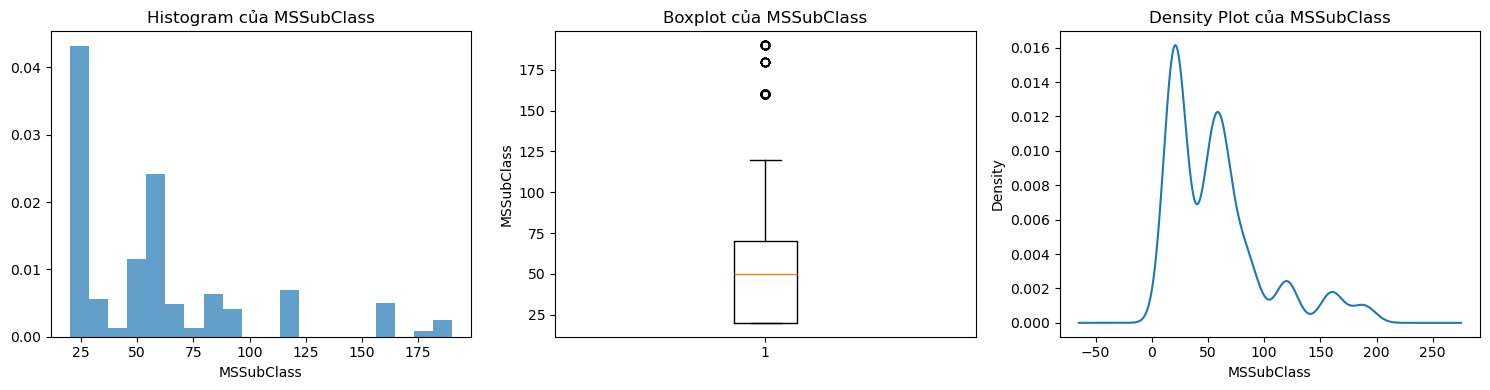

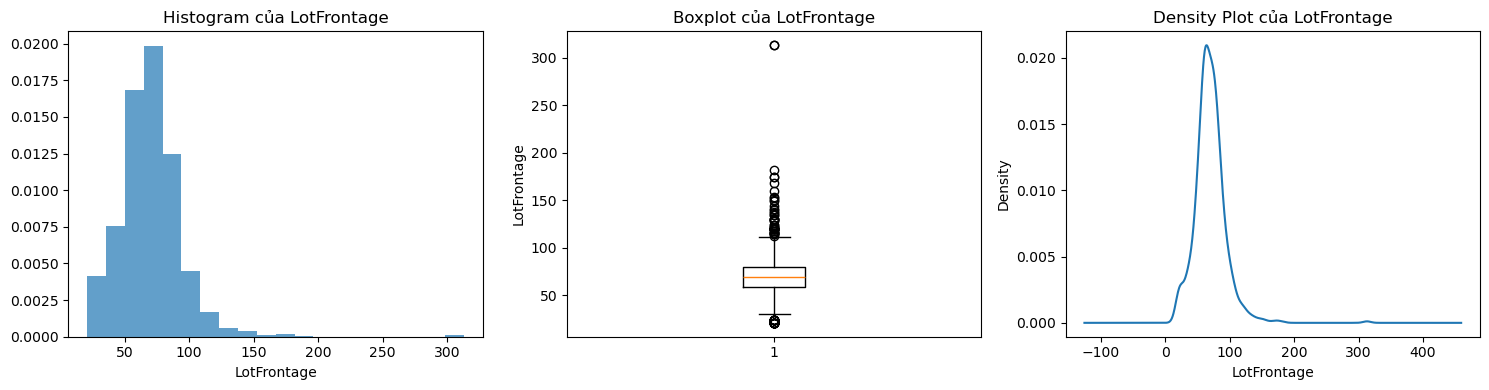

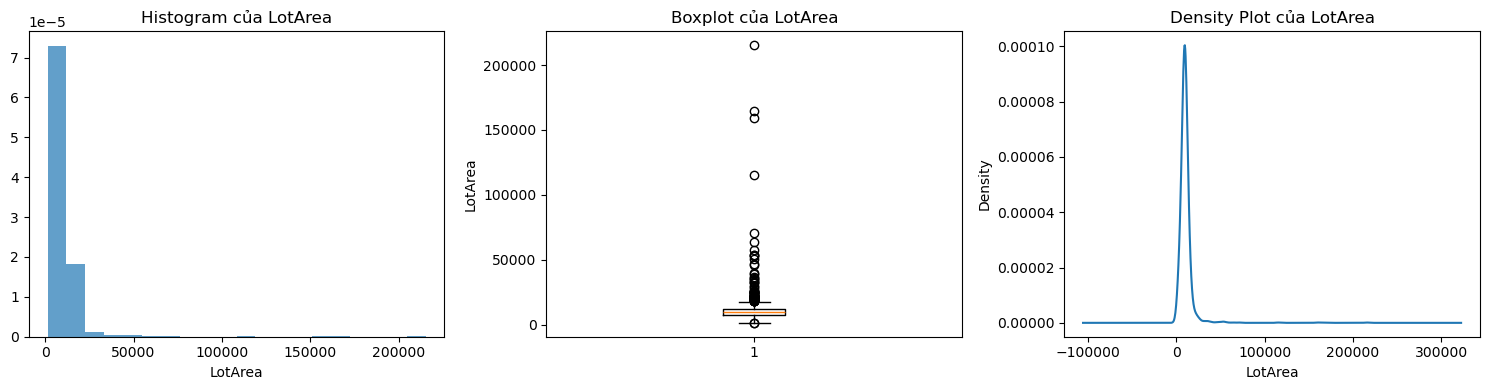

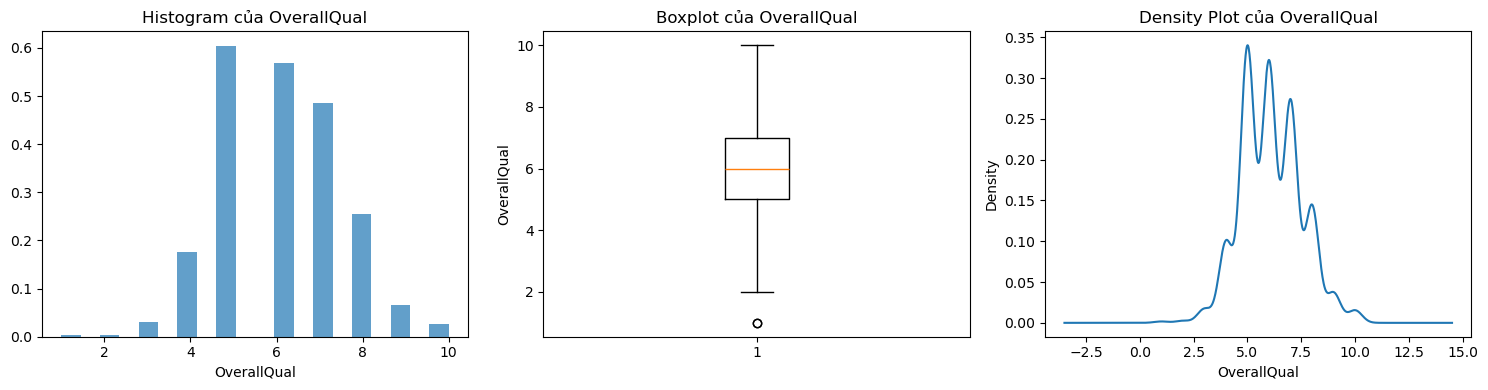

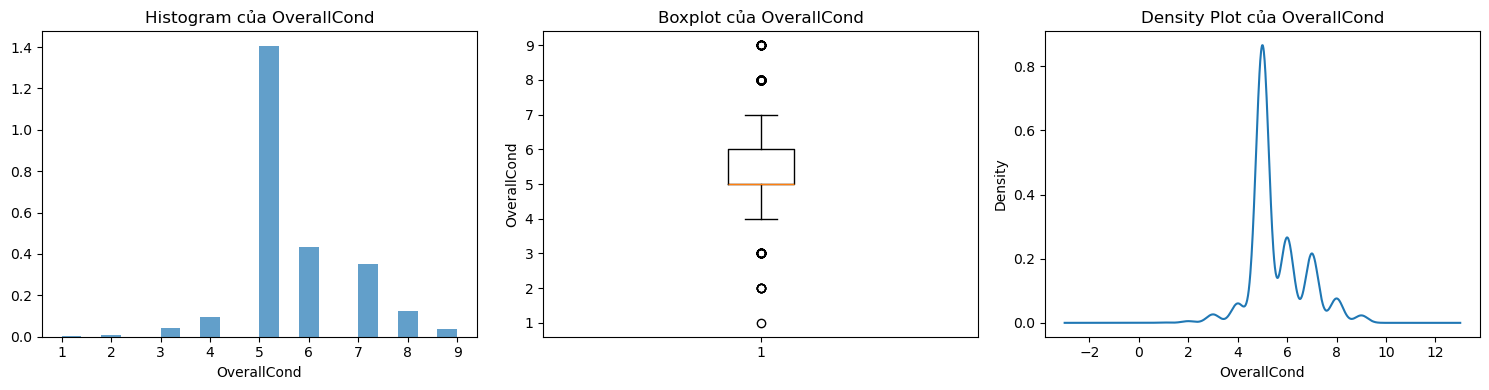

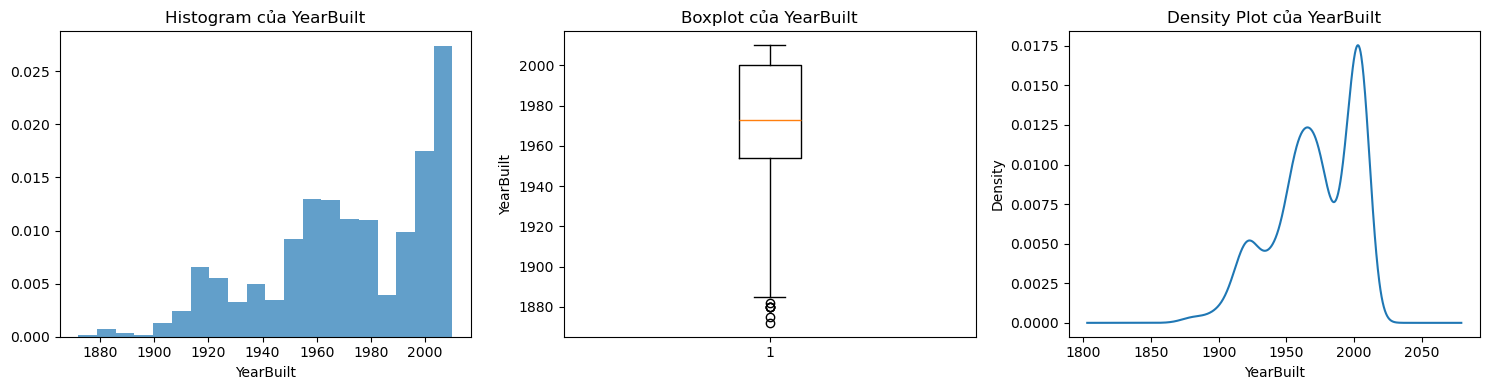

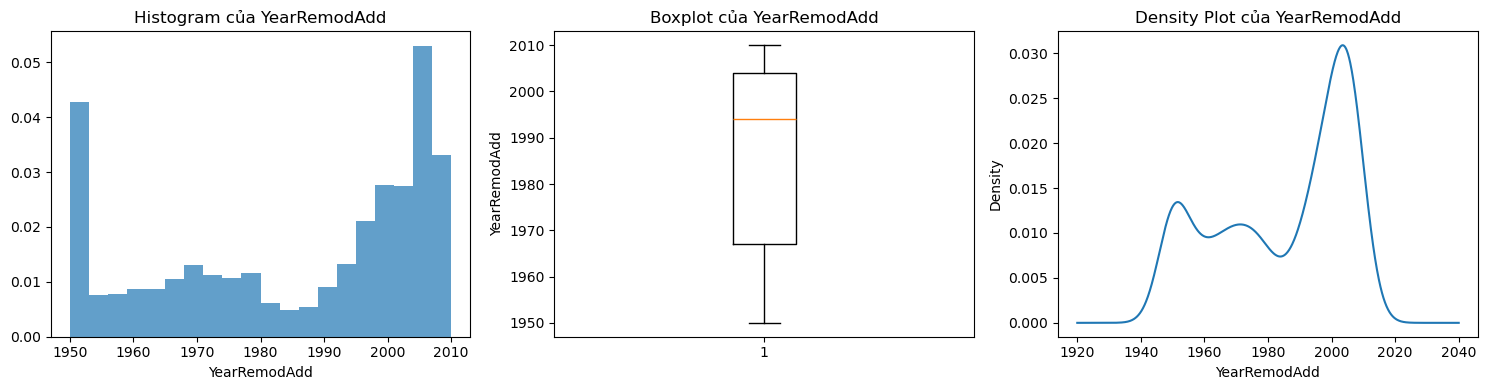

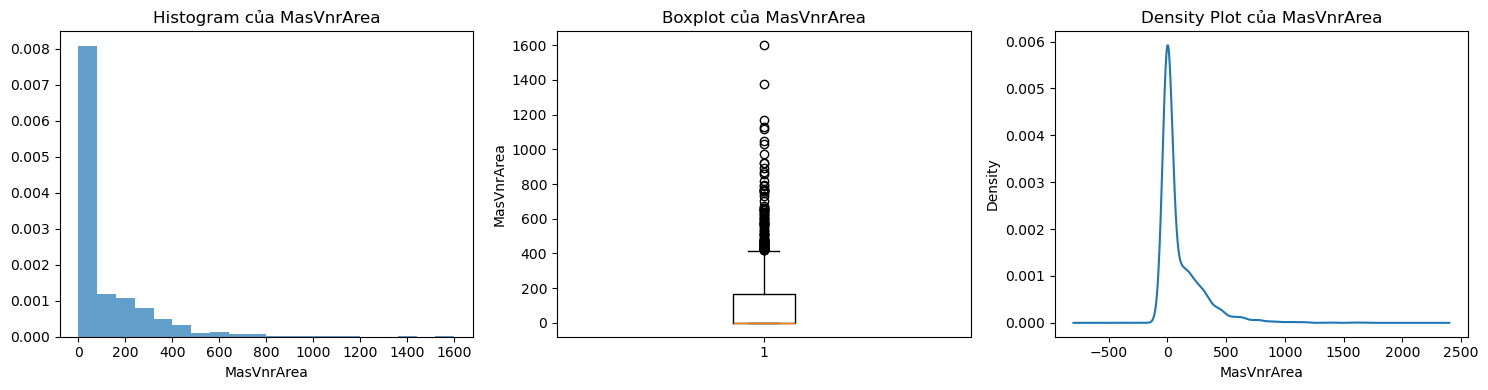

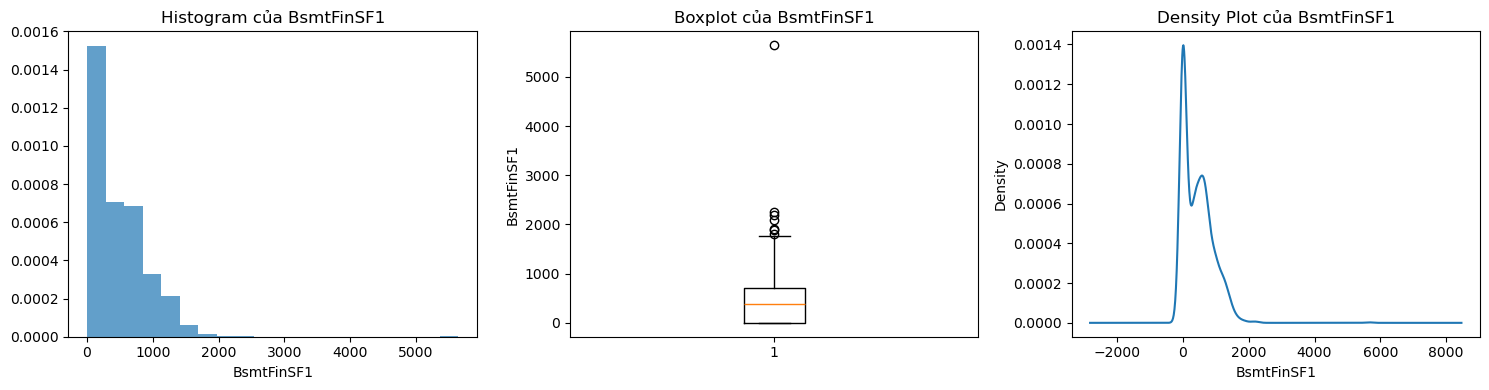

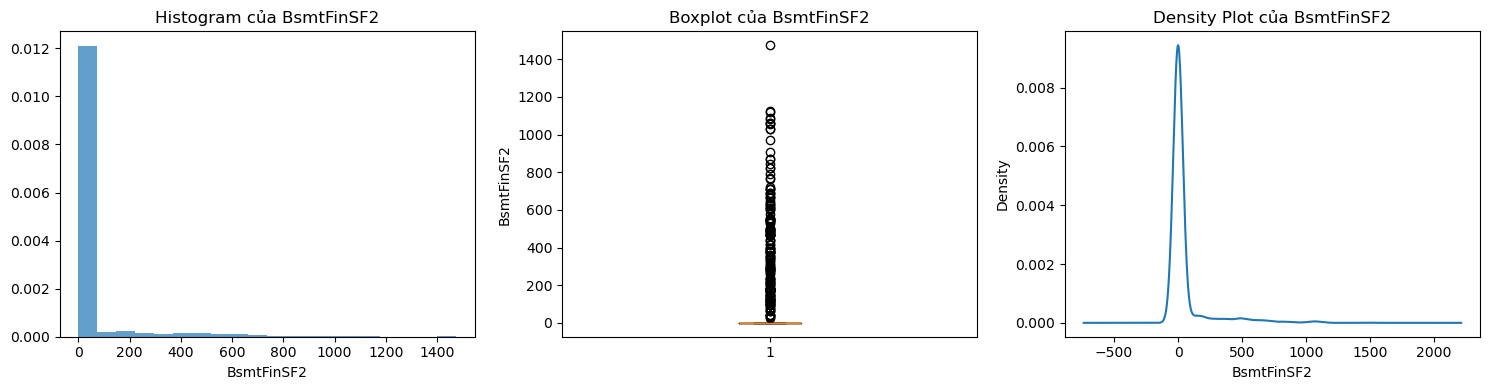

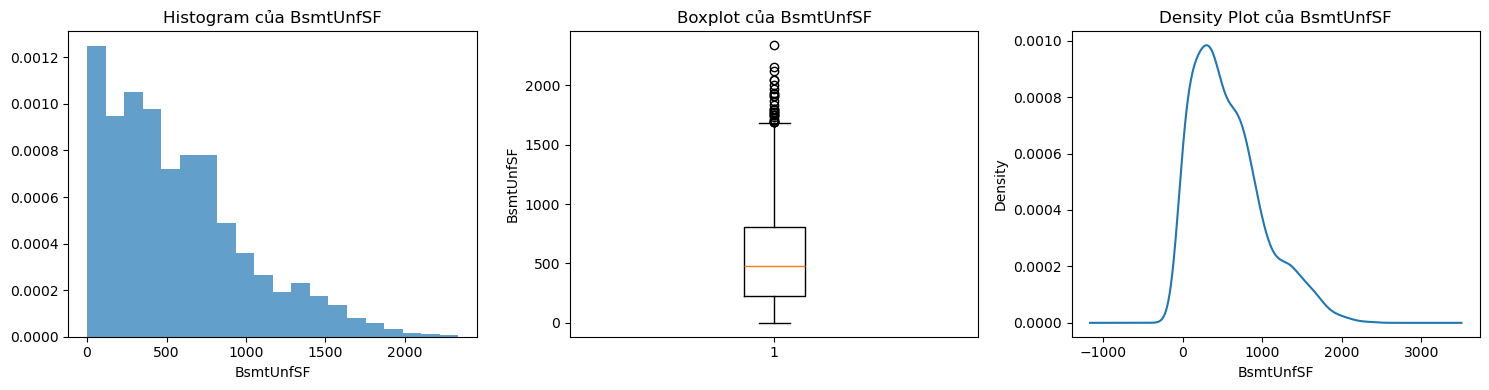

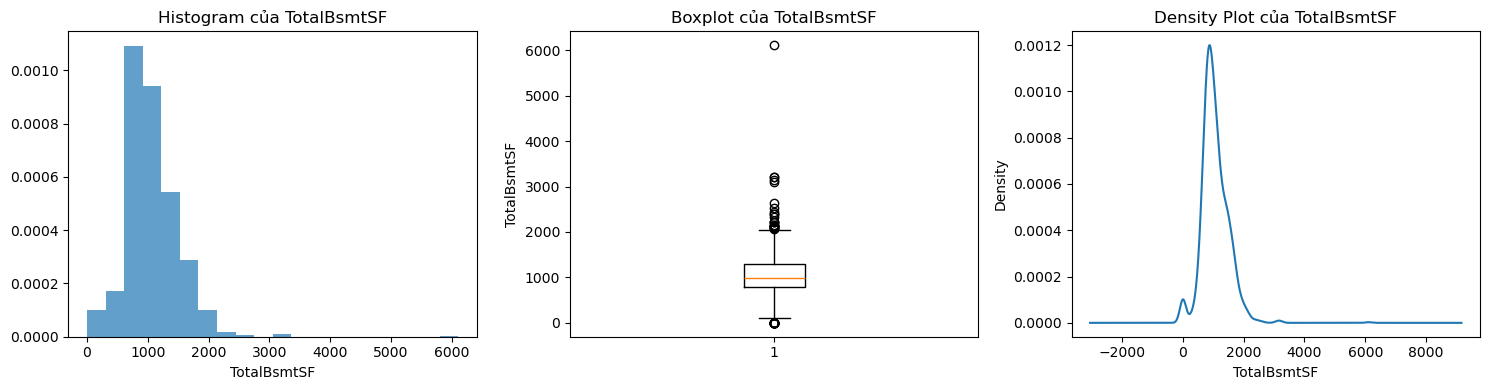

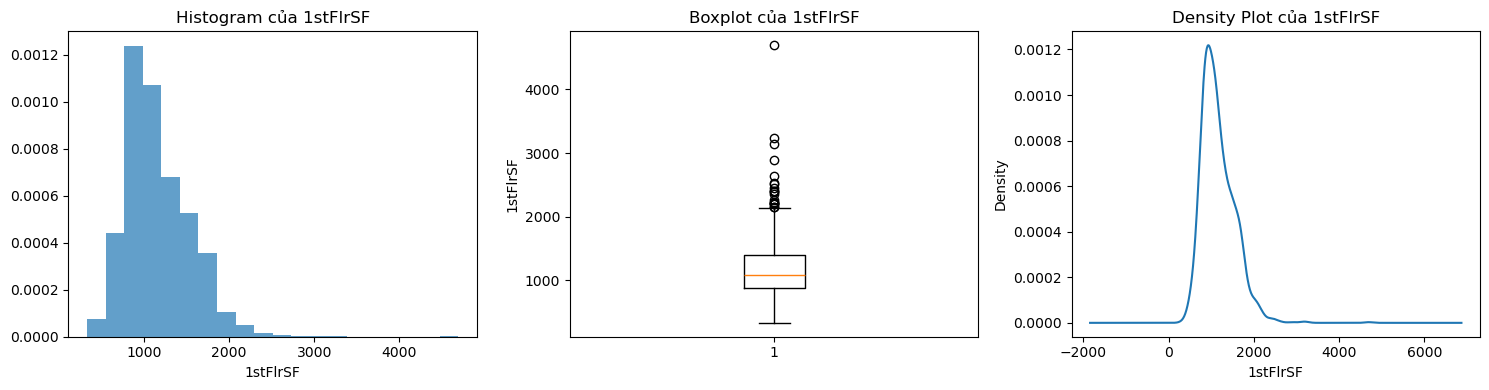

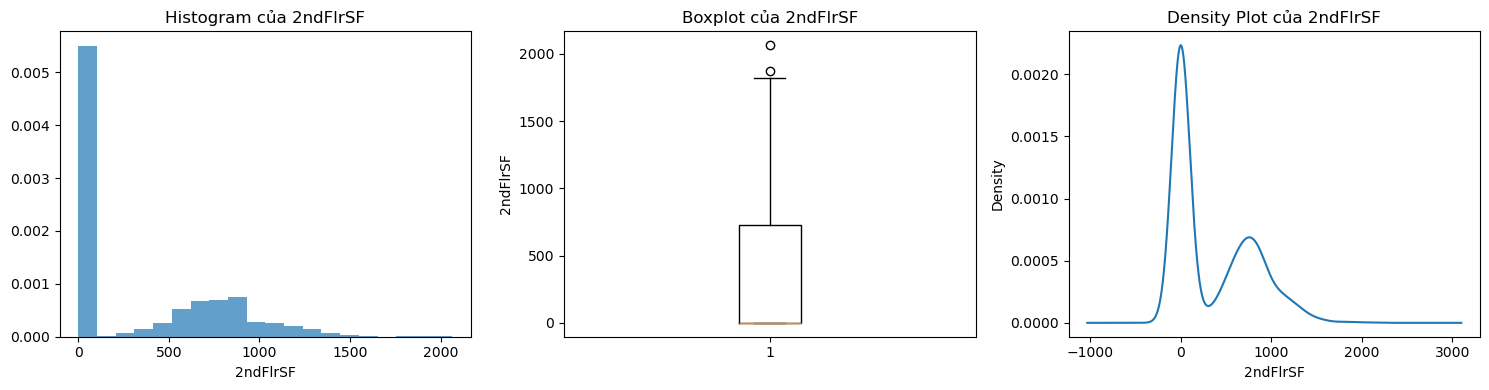

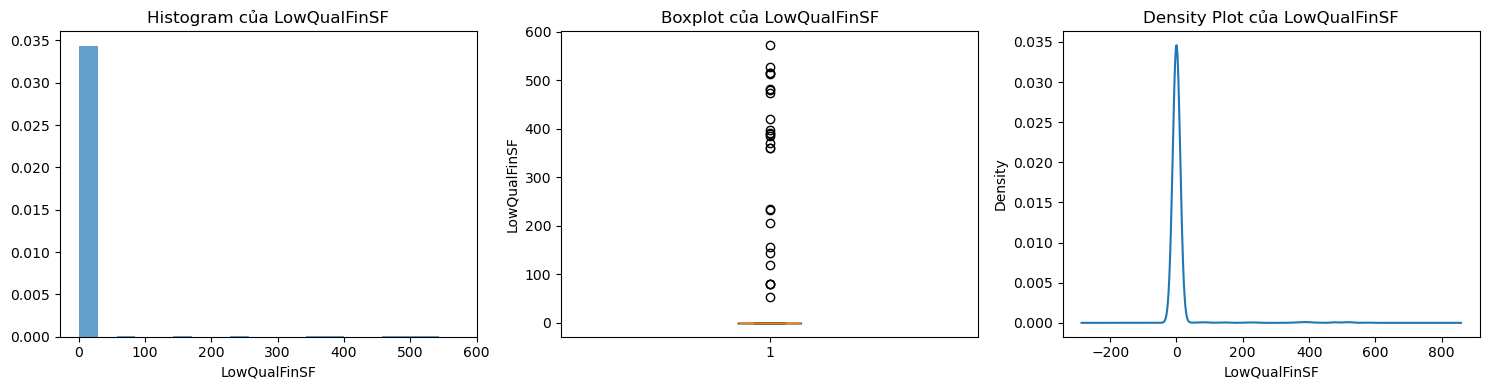

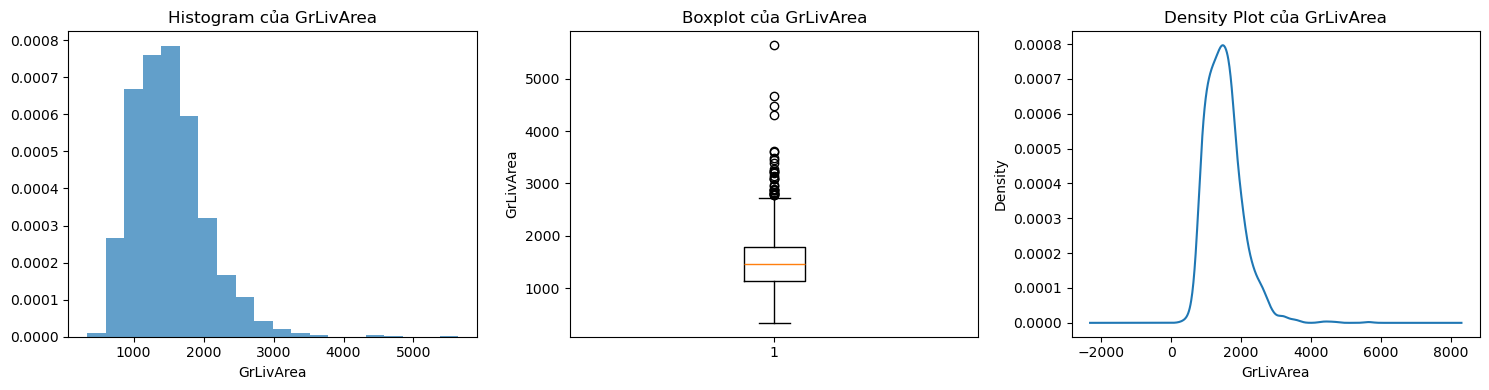

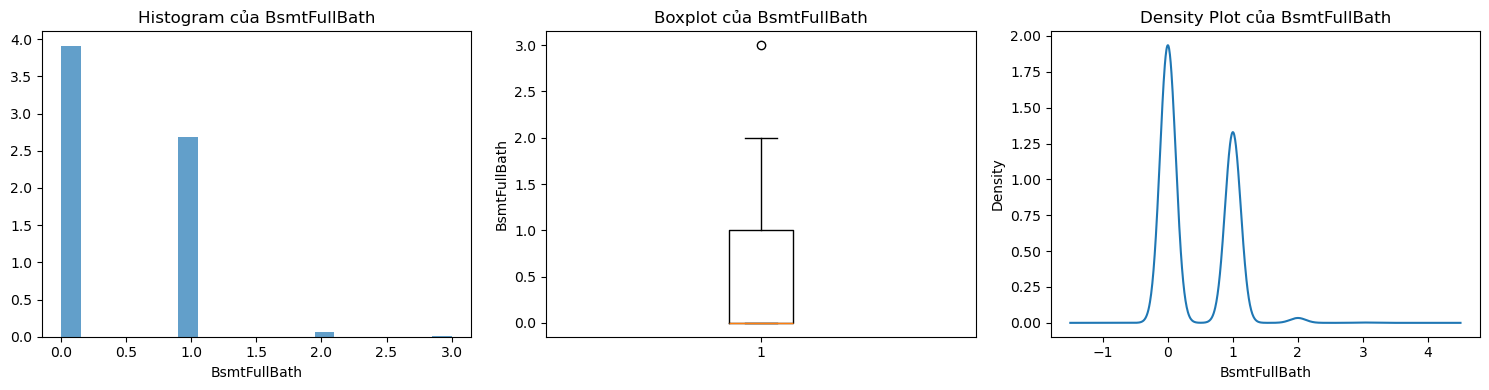

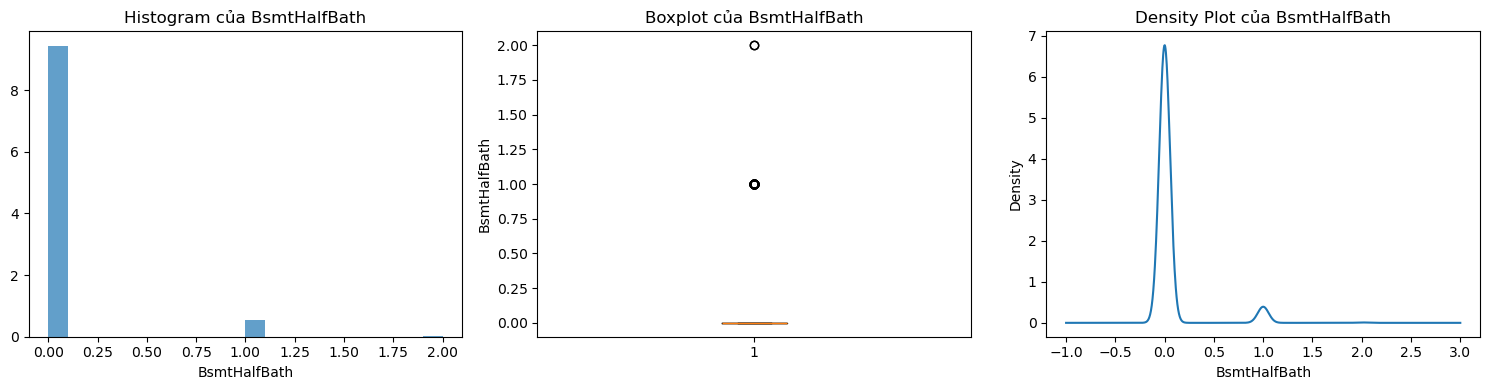

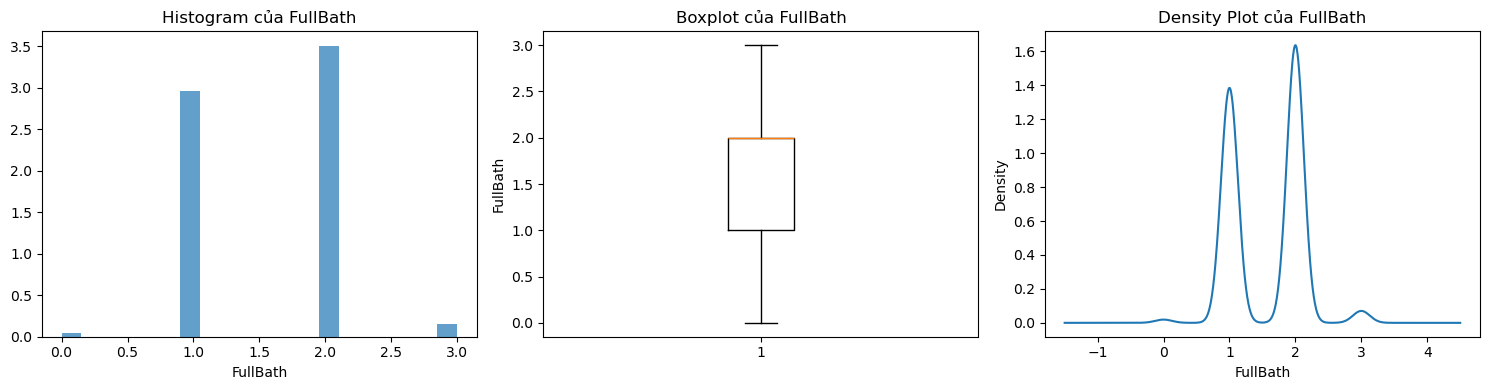

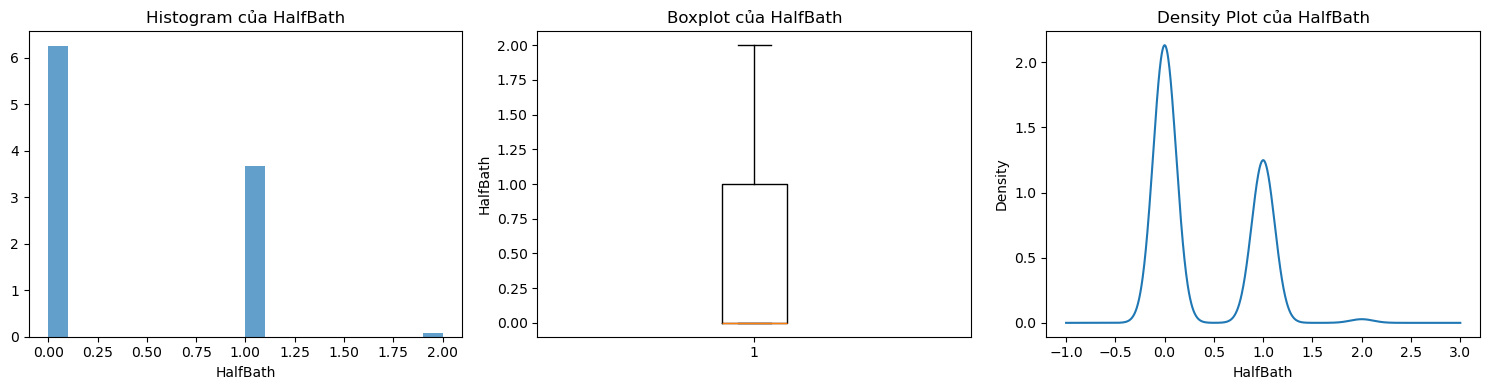

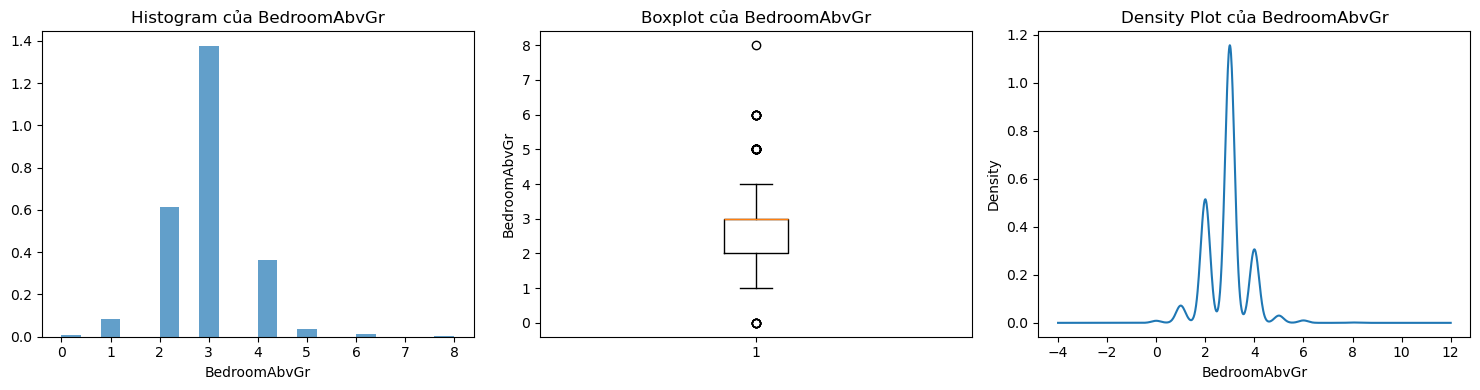

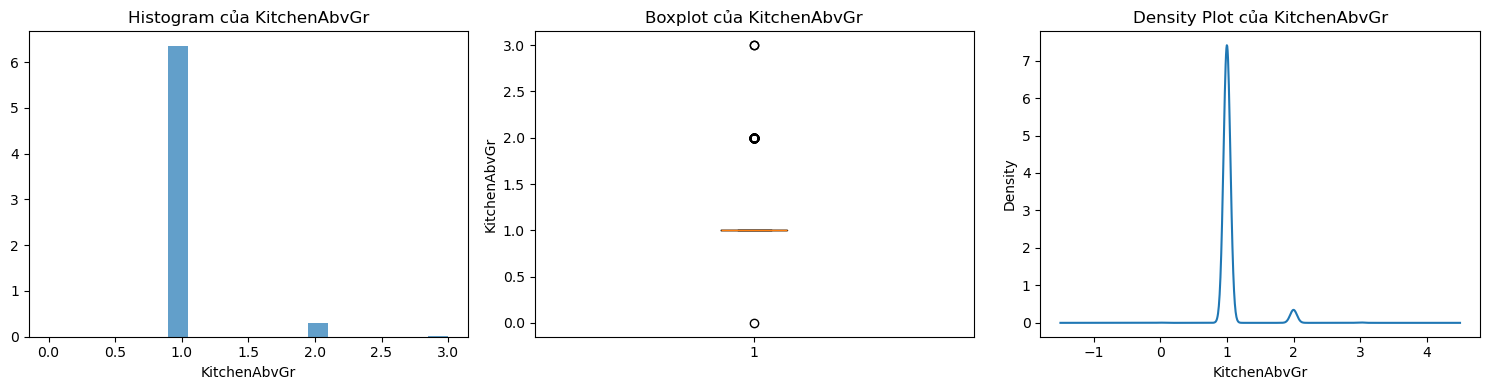

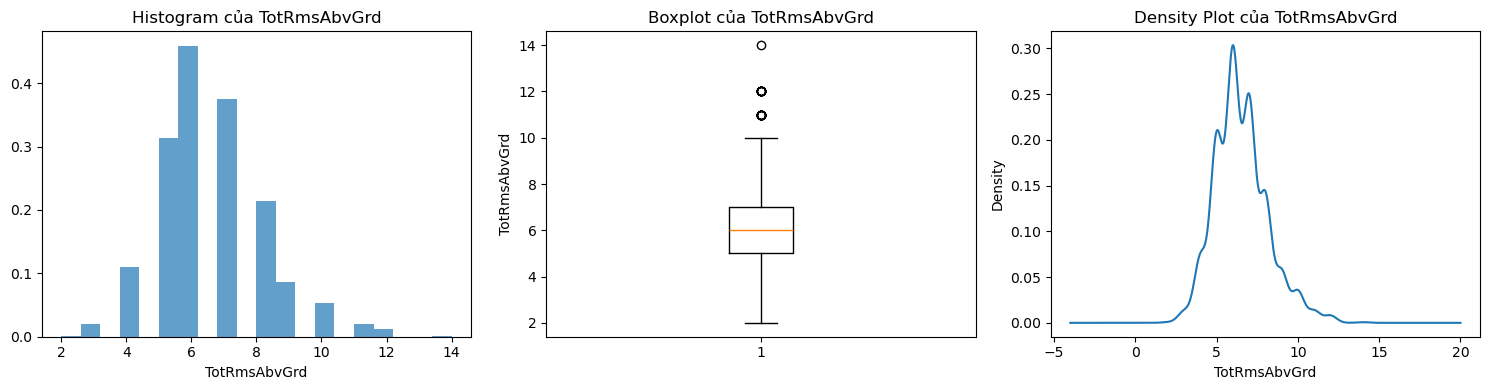

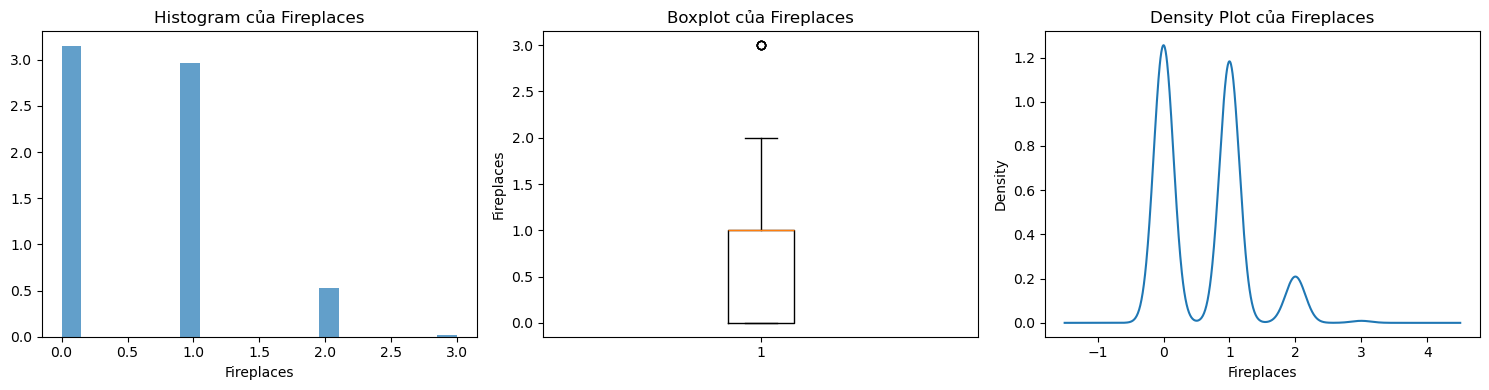

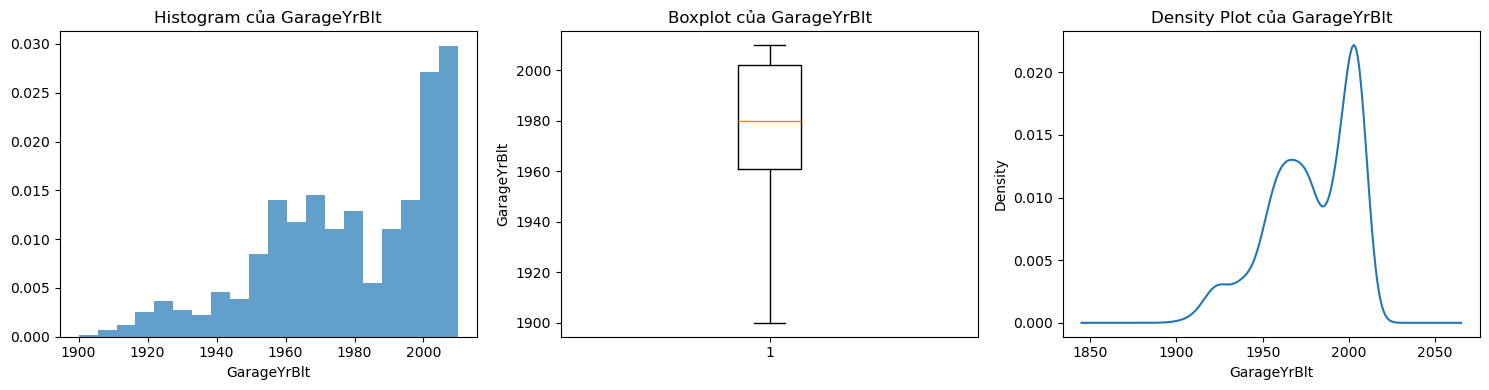

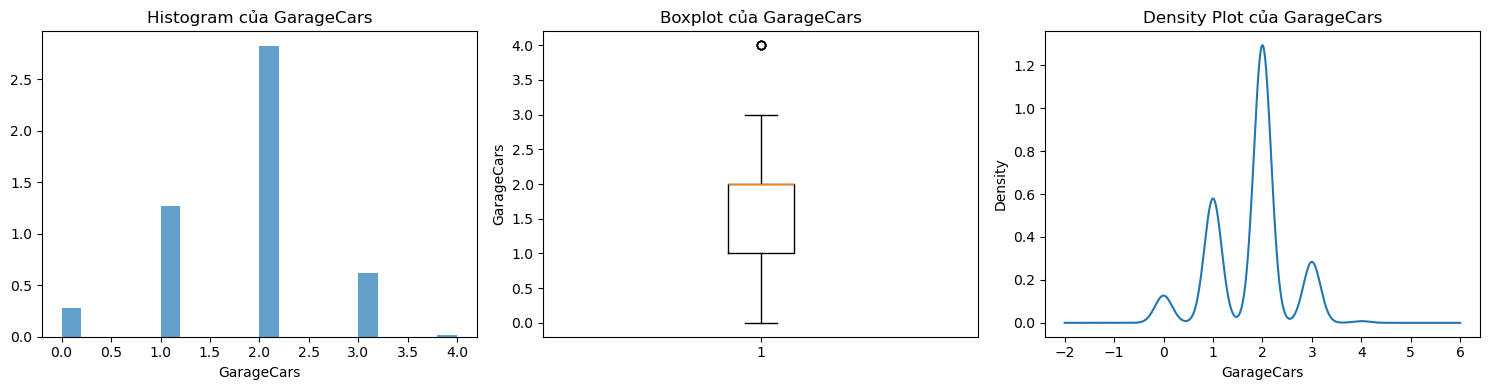

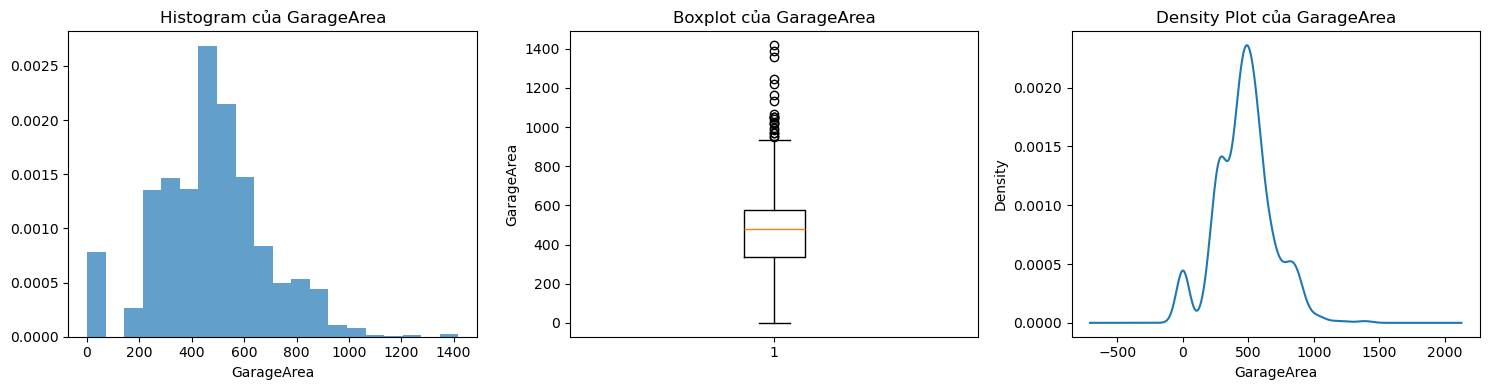

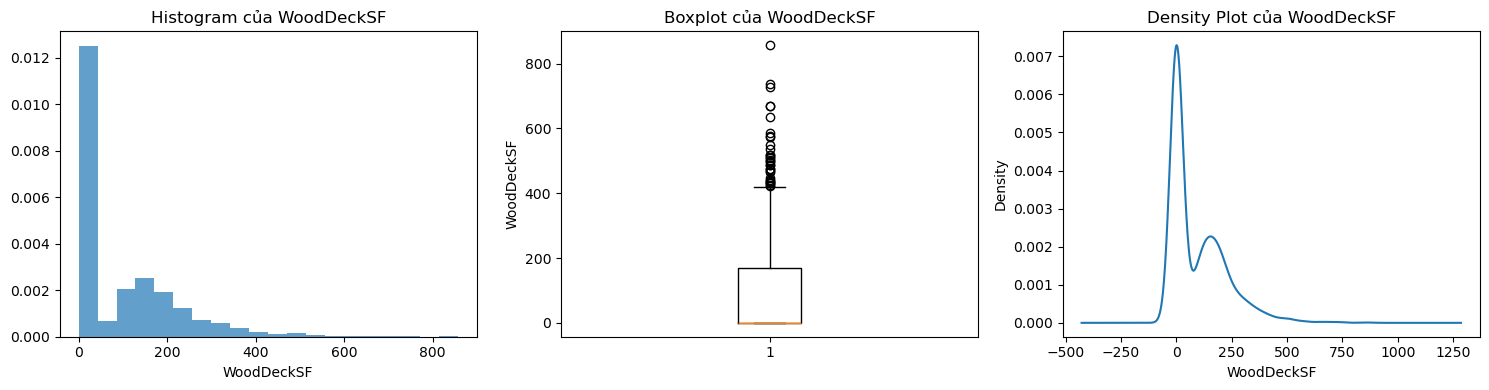

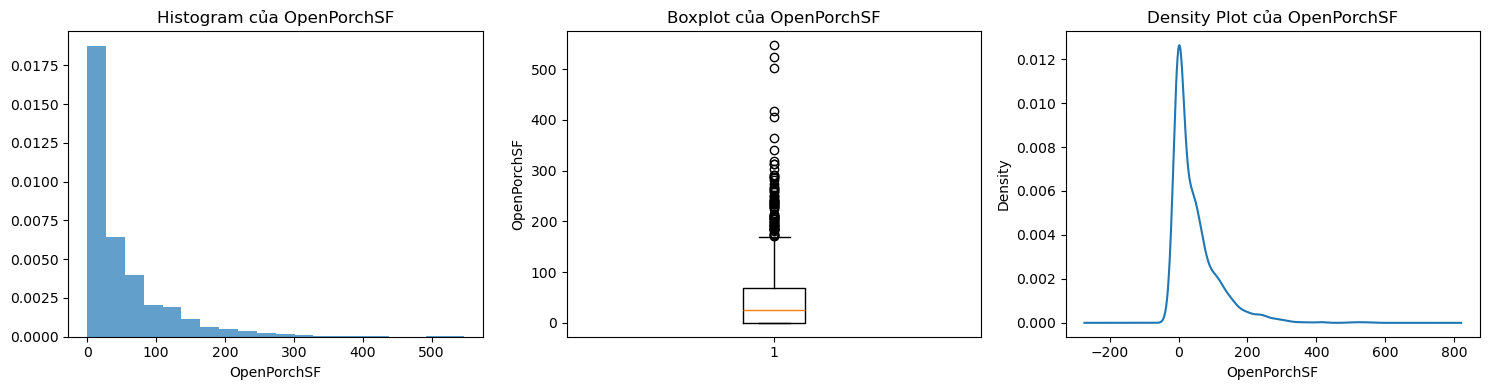

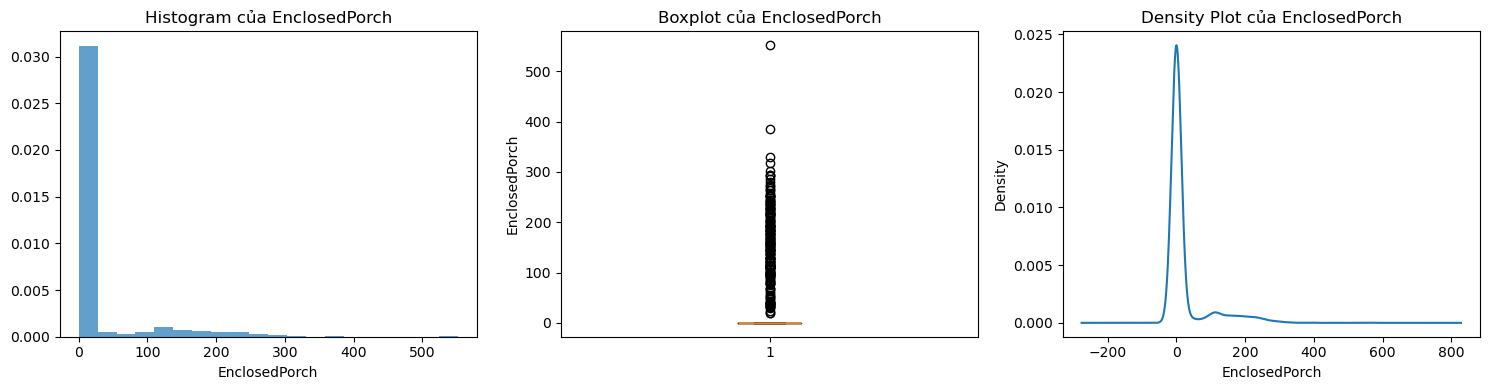

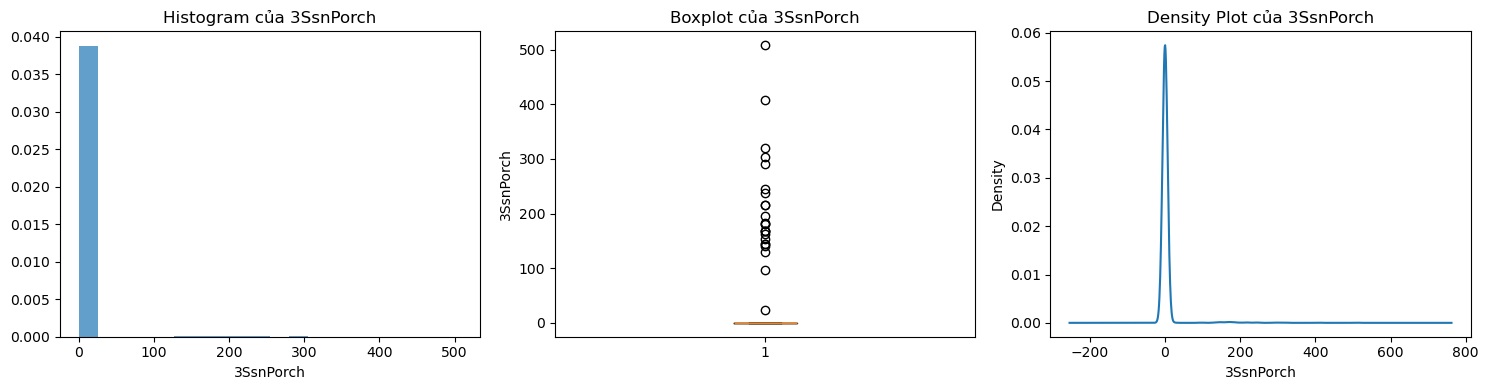

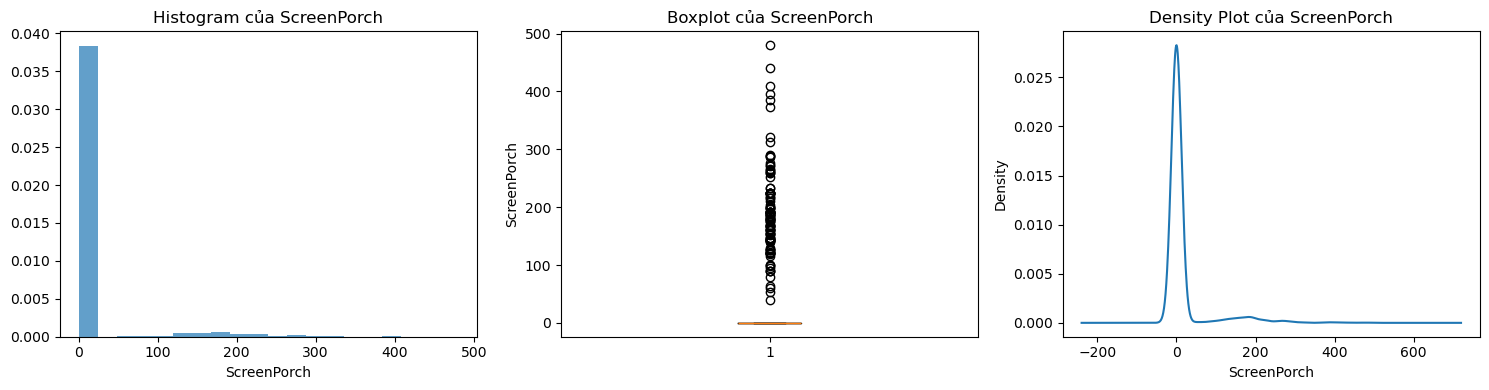

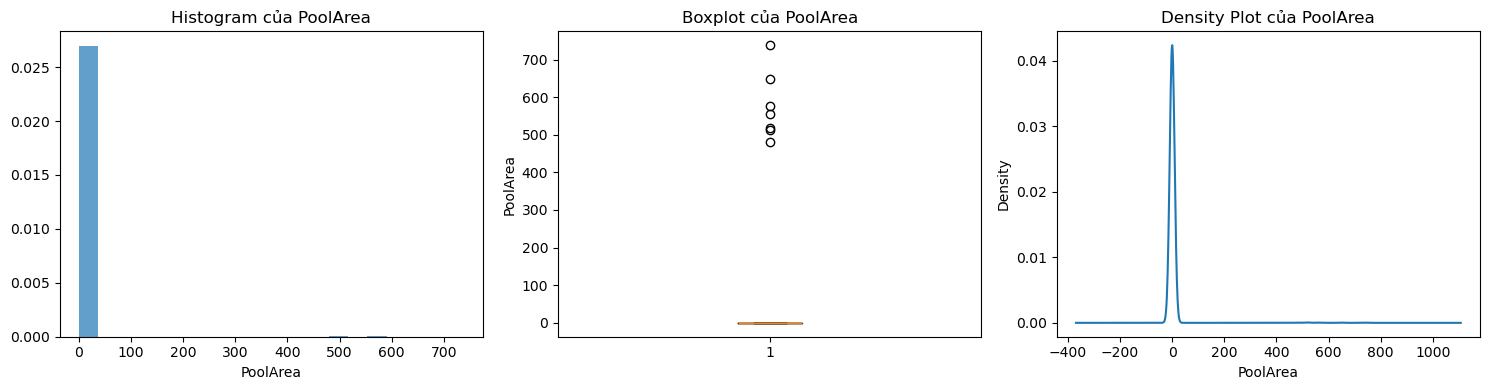

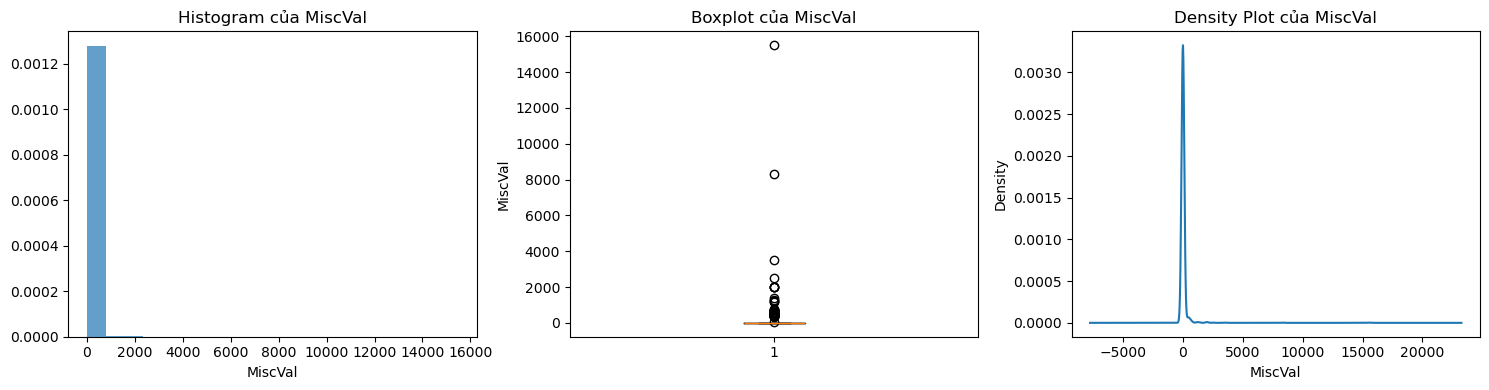

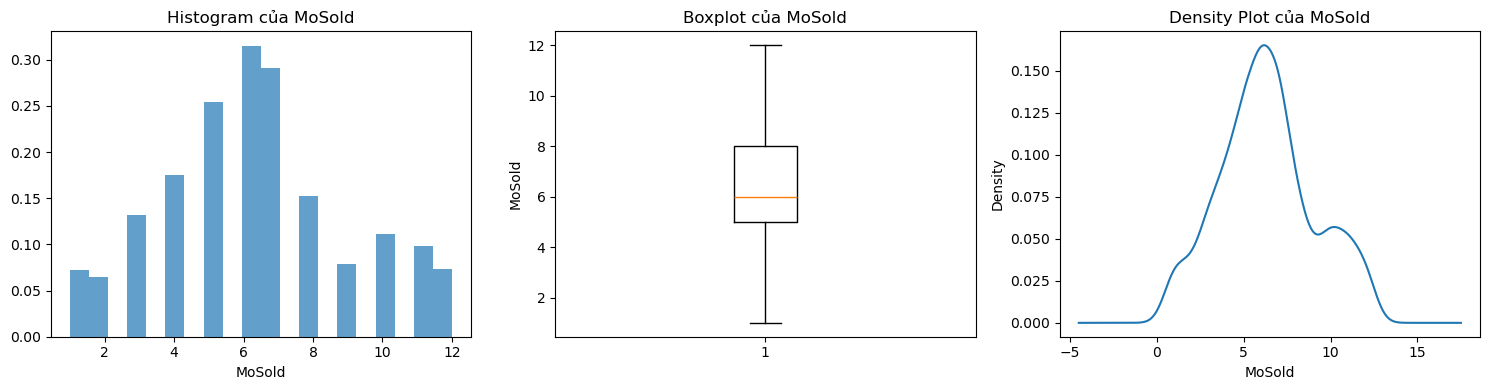

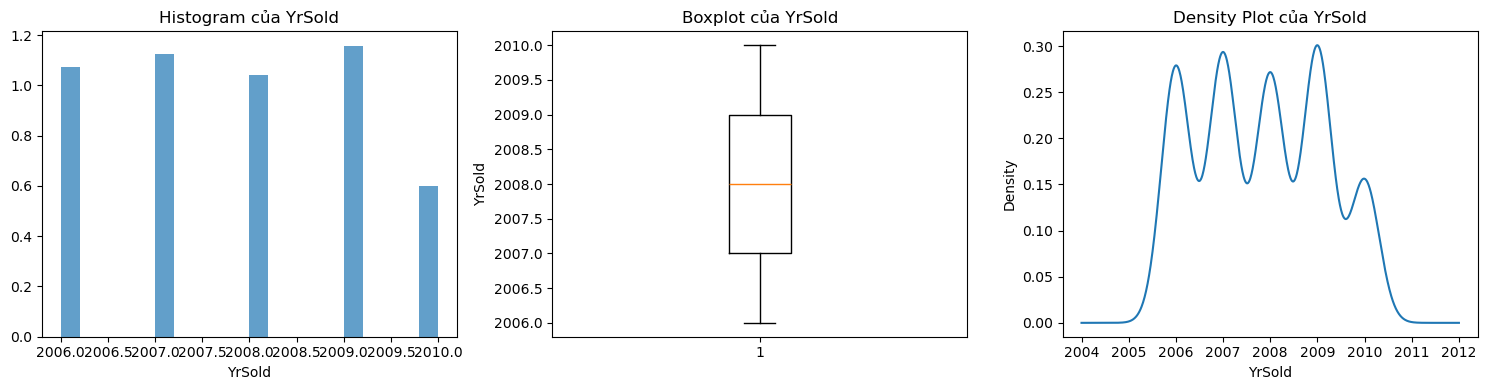

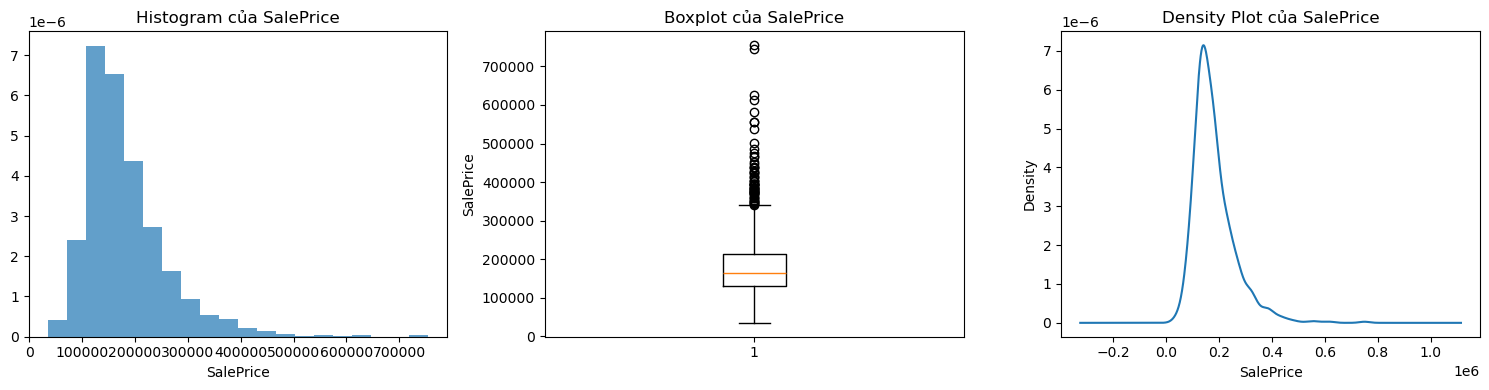

In [23]:
def numeric_visualization(df, numeric_columns=None):
    """
    Trực quan hóa các cột số với 3 biểu đồ: Histogram, Boxplot, Density Plot.
    """
    if numeric_columns is None:
        numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    for col in numeric_columns:
        data = df[col].dropna()
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # 1. Histogram đơn giản
        axes[0].hist(data, bins=20, alpha=0.7, density=True)
        axes[0].set_title(f'Histogram của {col}')
        axes[0].set_xlabel(col)
        
        # 2. Boxplot đơn giản
        axes[1].boxplot(data)
        axes[1].set_title(f'Boxplot của {col}')
        axes[1].set_ylabel(col)
        
        # 3. Density plot
        data.plot.kde(ax=axes[2])
        axes[2].set_title(f'Density Plot của {col}')
        axes[2].set_xlabel(col)
        
        plt.tight_layout()
        plt.show()

numeric_cols = df.drop(columns='Id').select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_visualization(df, numeric_columns=numeric_cols)

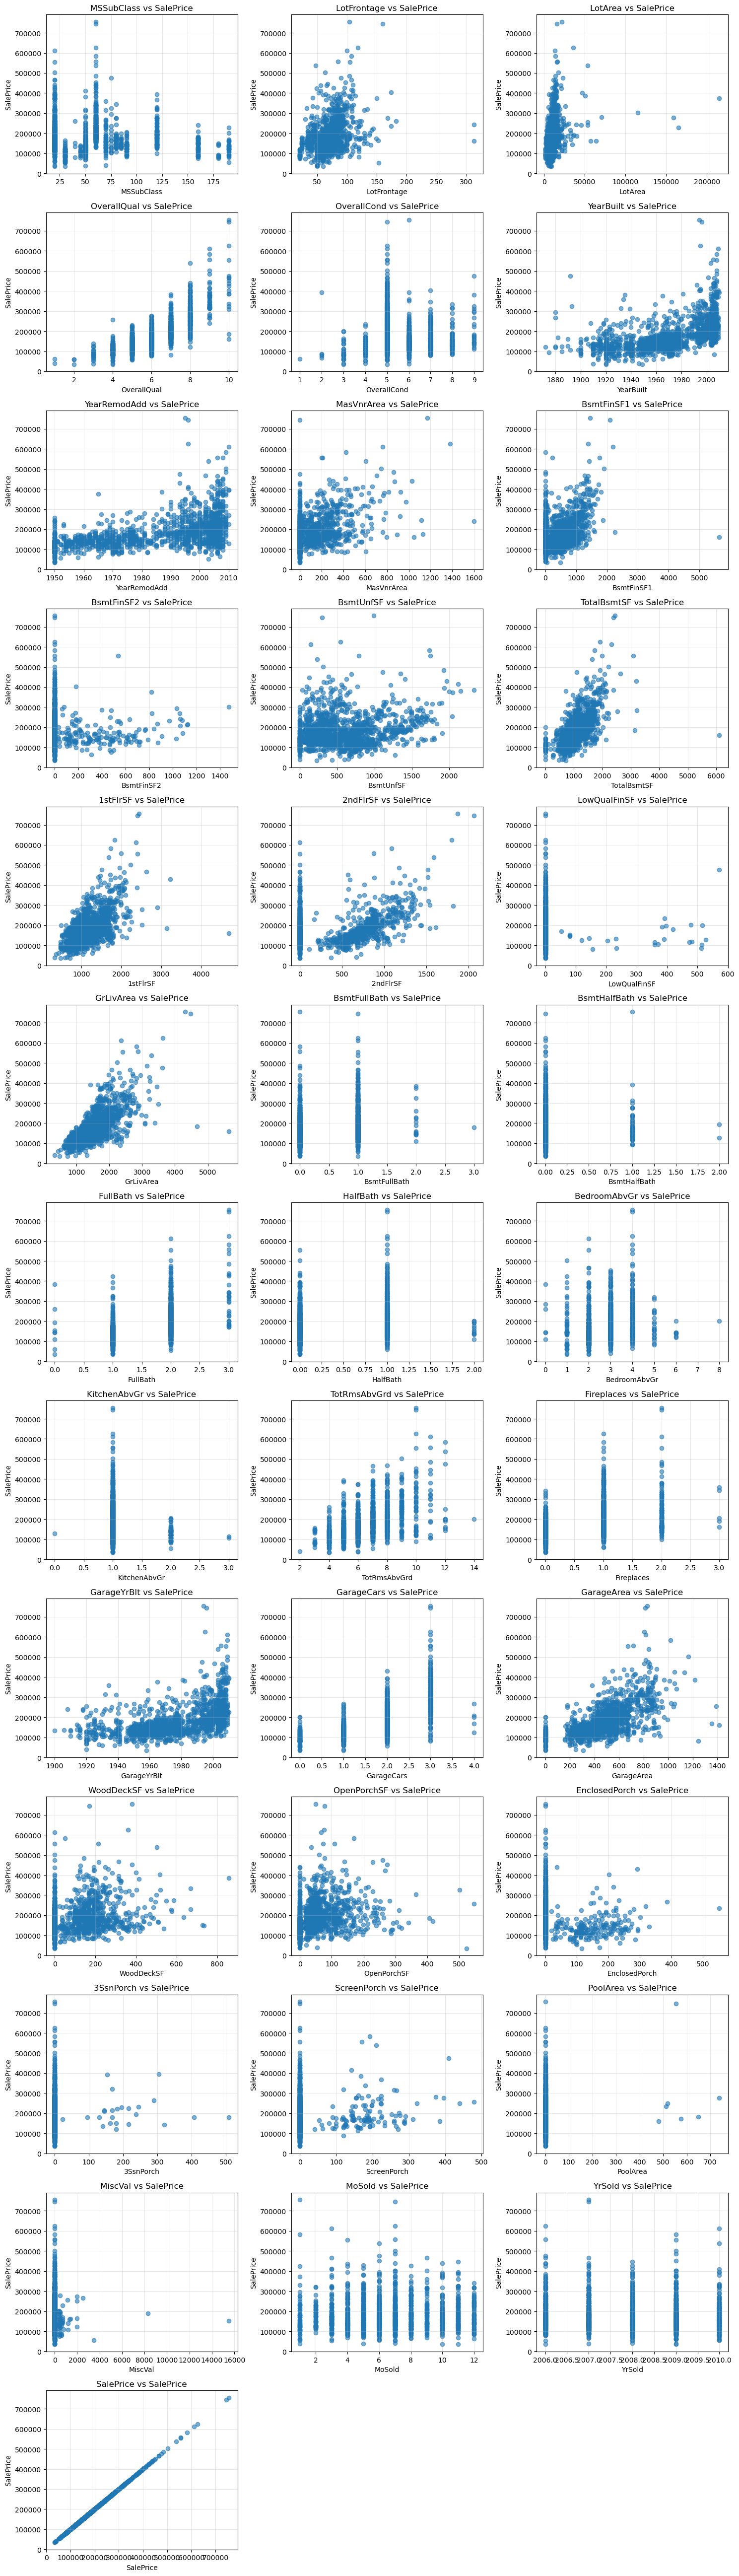

In [27]:
def plot_multiple_scatters(df, columns, target='Sale Price'):
    """
    Vẽ scatterplot cho nhiều cột với cột mục tiêu
    """
    n_cols = len(columns)
    n_rows = (n_cols + 2) // 3  # Tối đa 3 cột mỗi hàng
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        if i < len(axes):
            axes[i].scatter(df[col], df[target], alpha=0.6)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel(target)
            axes[i].set_title(f'{col} vs {target}')
            axes[i].grid(True, alpha=0.3)
    
    # Ẩn các subplot thừa
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Sử dụng
plot_multiple_scatters(df, numeric_cols, target='SalePrice')

## Tương quan dữ liệu

### Dữ liệu dạng số

<Figure size 3000x3000 with 0 Axes>

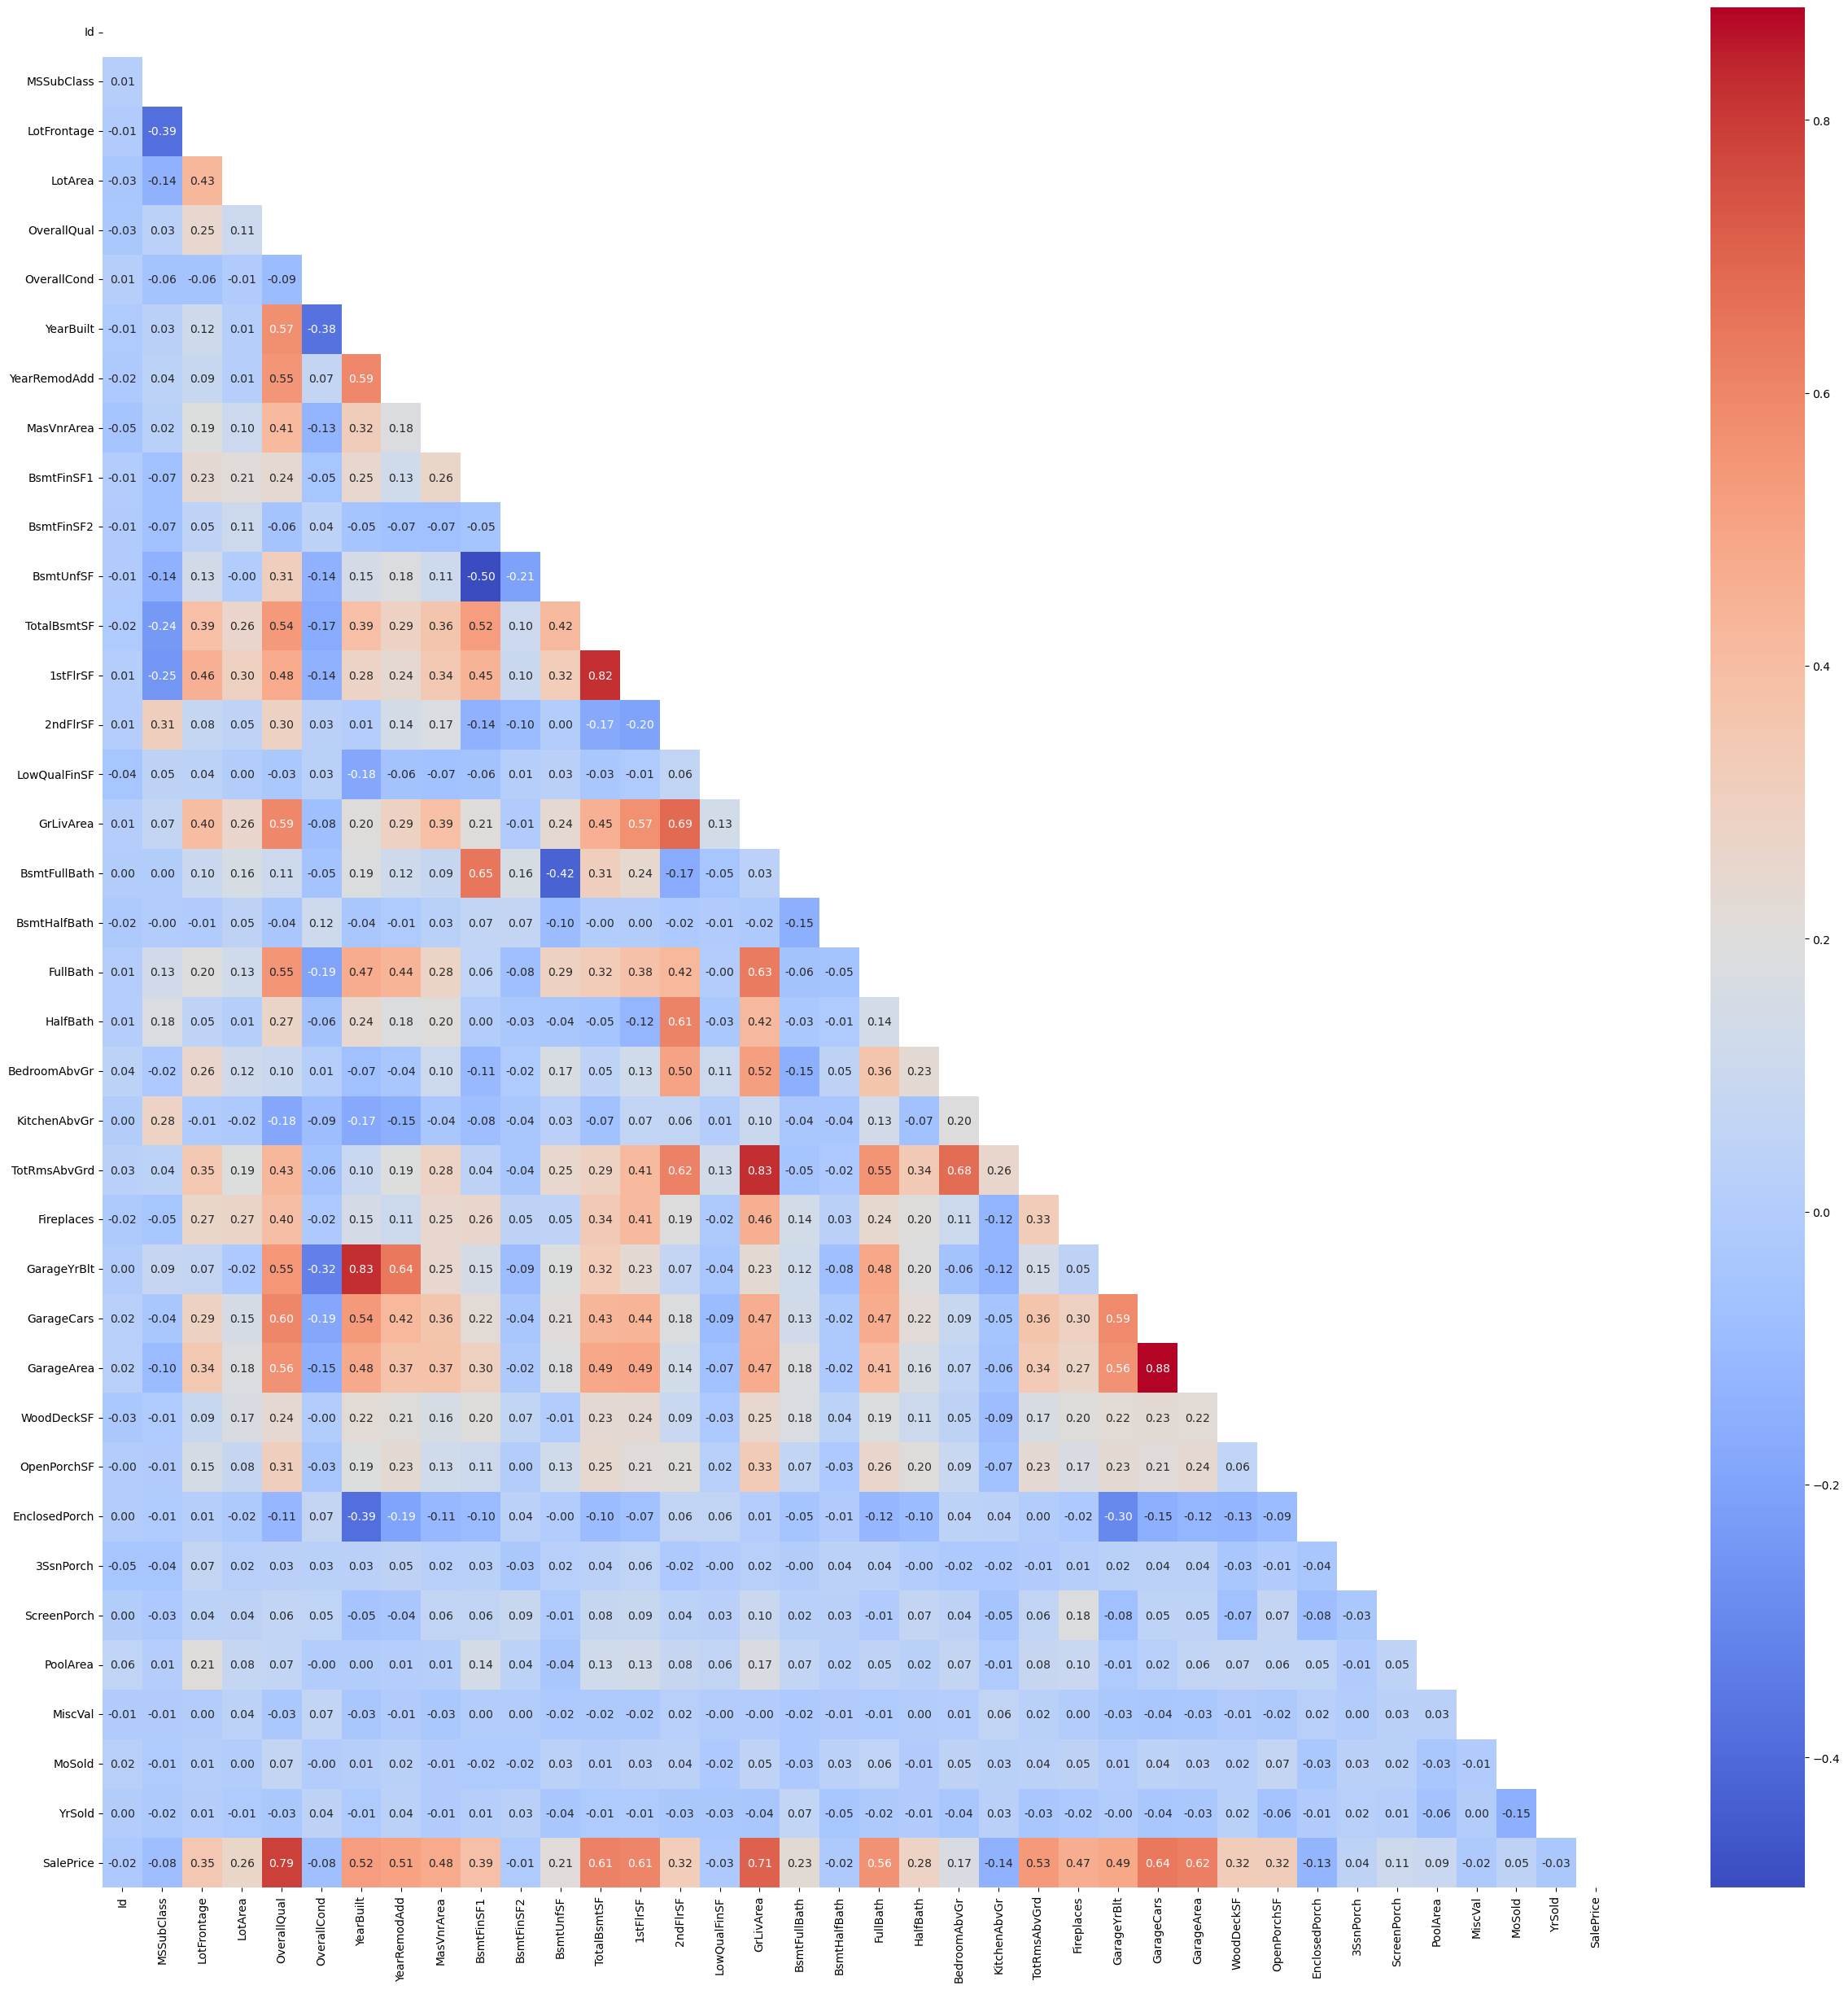

In [20]:
plt.figure(figsize=(30, 30))
corr = df.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

### Dữ liệu dạng category

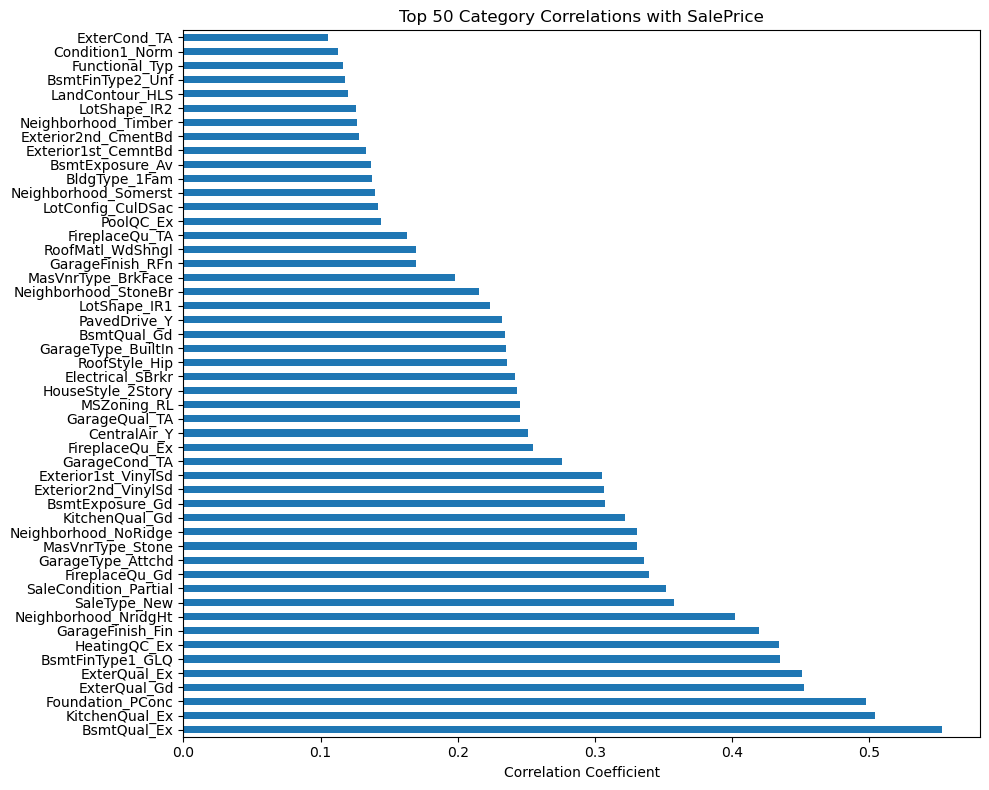

In [31]:
def plot_category_correlations(df, category_columns, target_column='SalePrice', top_n=20):
    """
    Tính và vẽ correlation của các cột category với target sau khi one-hot encode
    """
    # One-hot encode các cột category
    df_encoded = pd.get_dummies(df[category_columns], prefix=category_columns)
    
    # Thêm cột target vào
    df_encoded[target_column] = df[target_column]
    
    # Tính correlation
    corr_with_target = df_encoded.corr()[target_column].sort_values(ascending=False)
    
    # Lọc chỉ lấy correlation với các category (bỏ target itself)
    category_corr = corr_with_target[corr_with_target.index != target_column]
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    category_corr.head(top_n).plot(kind='barh')  # Top N correlation cao nhất
    plt.title(f'Top {top_n} Category Correlations with {target_column}')
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.show()
    
    return category_corr

# Sử dụng
category_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
corr_results = plot_category_correlations(df, category_columns, top_n=50)

# Kết thúc